In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
#customers = aggregate_customer(df_clean)

In [3]:
all_customers = pd.read_csv('customer_master_data.csv')

In [4]:
# Method 1: Using year column
customers_2025 = all_customers[all_customers['year'] == 2025]

# Method 2: Using period column
customers_2025 = all_customers[all_customers['period'] == '2025']

# Method 3: Using date range
customers_2025 = all_customers[
    (all_customers['first_quote_date'] >= '2025-01-01') & 
    (all_customers['first_quote_date'] <= '2025-12-31')
]

print(f"2025 customers: {len(customers_2025):,}")

2025 customers: 9,986


In [5]:
customers = customers_2025


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.356779            7464           2663.0
True                      0.450436            2522           1136.0

Chi-square p-value: 6.714639e-17
Statistically significant: YES

Conversion without issues: 35.68%
Conversion with issues: 45.04%
Difference: 9.4 percentage points
Customer-level finding: +9.4 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.40
  With issues: 1.59
  Ratio: 1.14x

avg_quote_amount:
  No issues: 5835.41
  With issues: 9668.17
  Ratio: 1.66x

max_quote_amount:
  No issues: 6240.72
  With issues: 10588.18
  Ratio: 1.70x

customer_duration_days:
  No issues: 9.13
  With issues: 13.12
  Ratio: 1.44x

price_range:
  No issues: 892.37
  With issues: 1733.21
  Ratio: 1.94x

multiple_quotes:
  No issues: 0.2

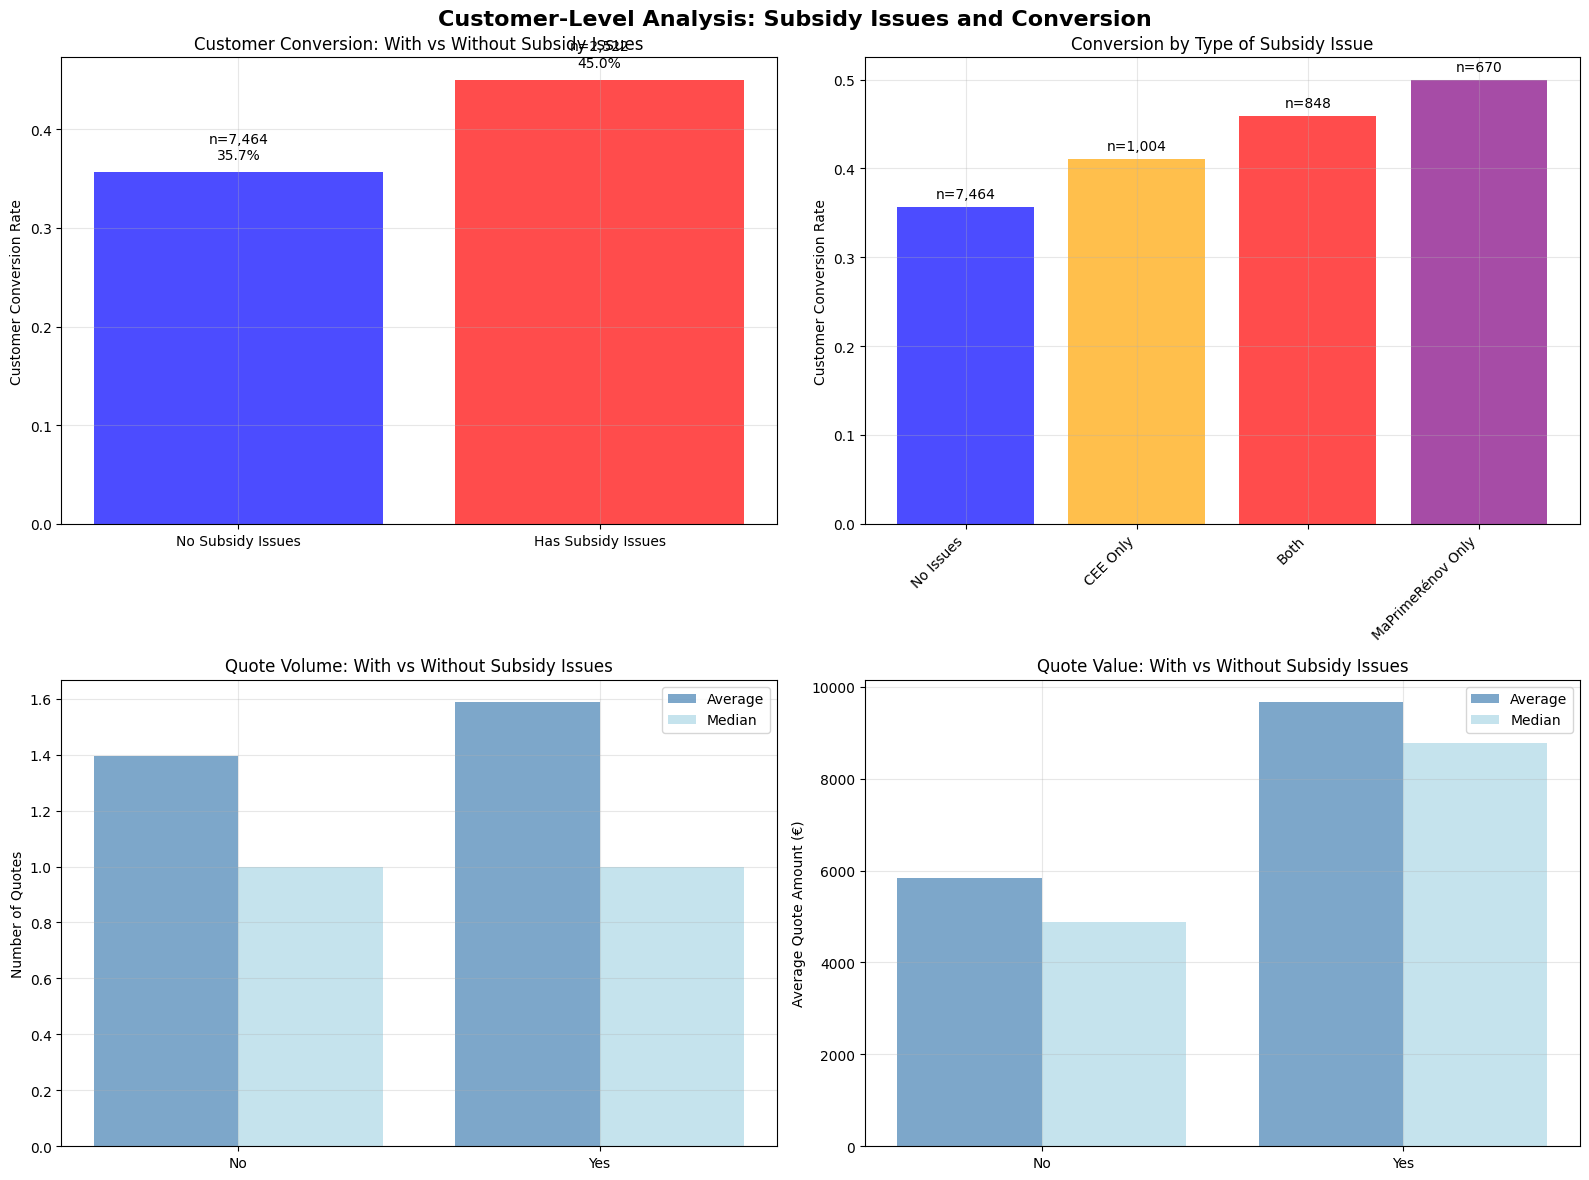


Policy Suspension Impact

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200
Unique values in during_suspension: [False  True]

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.386102   7296
During Suspension  0.366425   2347

Suspension impact p-value: 0.0924
Statistically significant: NO

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
during_suspension                                             
False                    19.2    30.6       15.7   12.3   22.2
True                     43.7    23.8        8.8    8.0   15.8


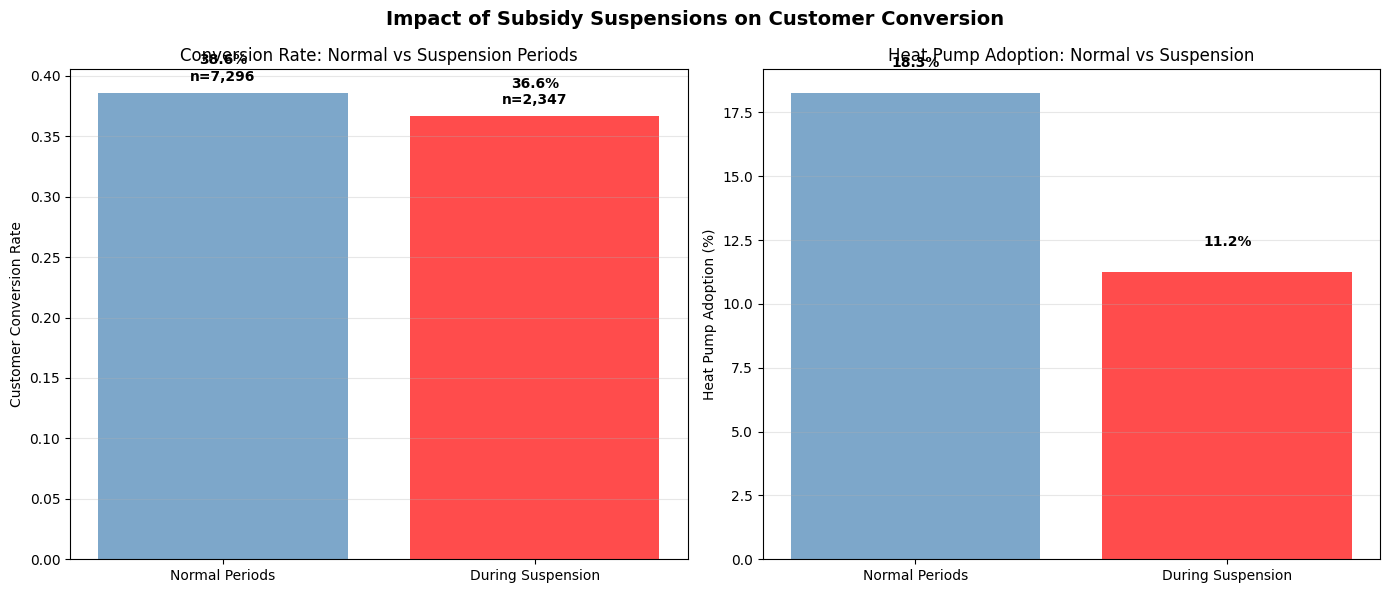

Unique values in main_product_family:
main_product_family
Chaudière                           2886
Climatisation                       2475
Poêle                               2033
Pompe à chaleur                     1369
ECS : Chauffe-eau ou adoucisseur     550
Photovoltaïque                       255
Appareil hybride                     109
Emetteur de chauffage  ou chappe      98
Autres                                87
Unknown                               58
Accessoire de pose                    31
Produit VMC                           29
Plomberie Sanitaire                    6
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           2886
Climatisation                       2475
Poêle                               2033
Pompe à chaleur                     1369
ECS : Chauffe-eau ou adoucisseur     550
Photovoltaïque                       255
Appareil hybride                     109
Emetteur de chauffage  ou chappe      98
Autres              

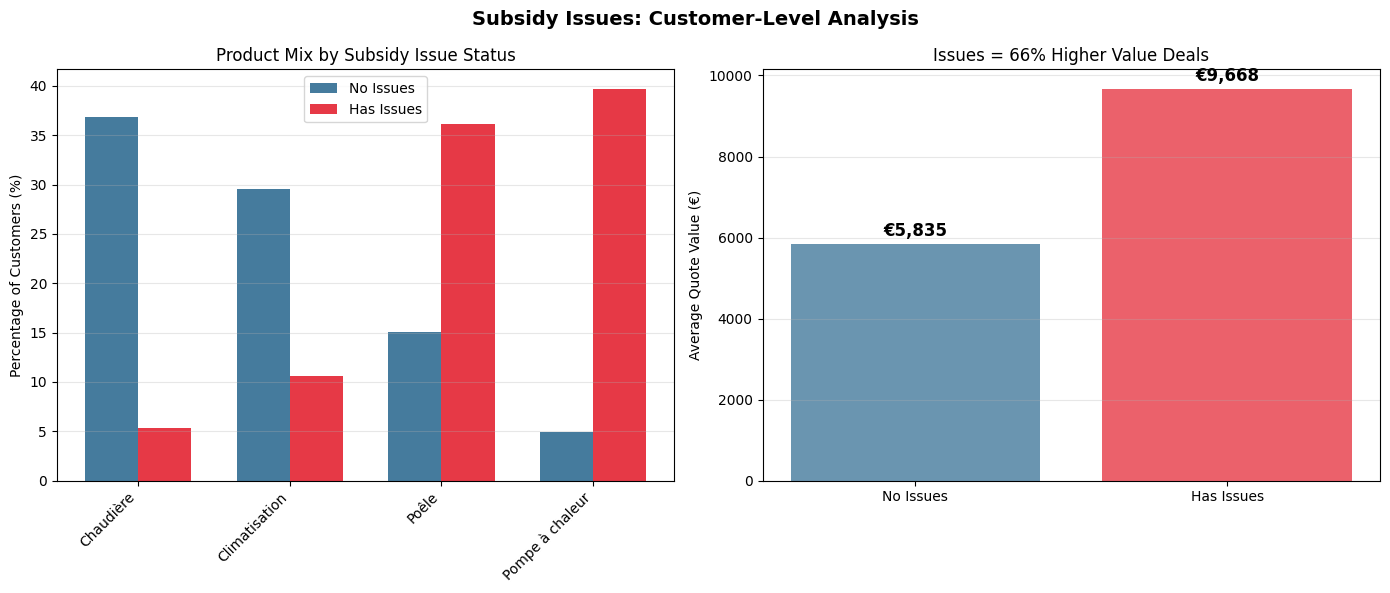


Threshold effect

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200


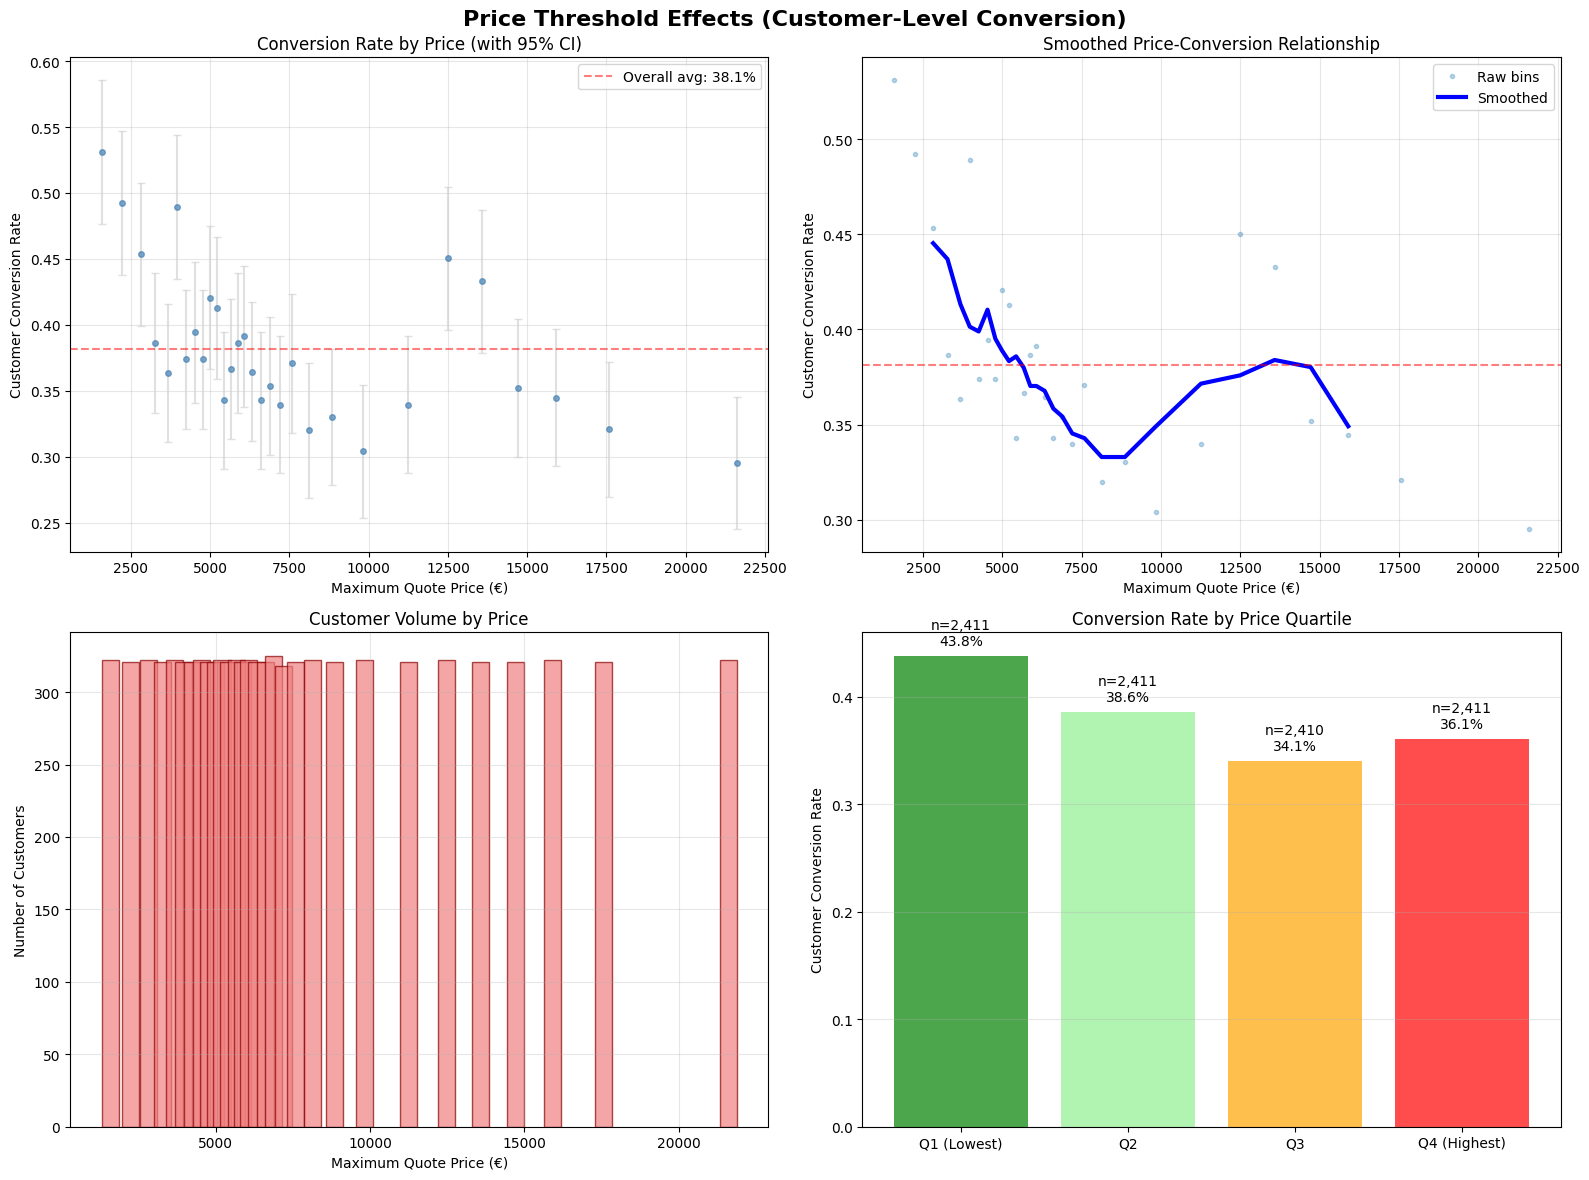


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 43.8% (n=2,411)
  Q2: 38.6% (n=2,411)
  Q3: 34.1% (n=2,410)
  Q4 (Highest): 36.1% (n=2,411)

Difference between lowest and highest quartile: 7.7 percentage points

Sweet spots (above-average conversion):
  €1,588: 53.1% (n=322)
  €2,240: 49.2% (n=321)
  €2,816: 45.3% (n=322)
  €3,269: 38.6% (n=321)
  €3,971: 48.9% (n=321)
  €4,530: 39.4% (n=322)
  €4,986: 42.1% (n=321)
  €5,207: 41.3% (n=322)
  €5,880: 38.6% (n=321)
  €6,069: 39.1% (n=322)
  €12,490: 45.0% (n=322)
  €13,582: 43.3% (n=321)

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
price_quartile                                                
Q1_Low                   31.2    35.0        0.4   26.0    7.4
Q2_MidLow                20.2    35.9        0.4    4.0   39.5
Q3_MidHigh           

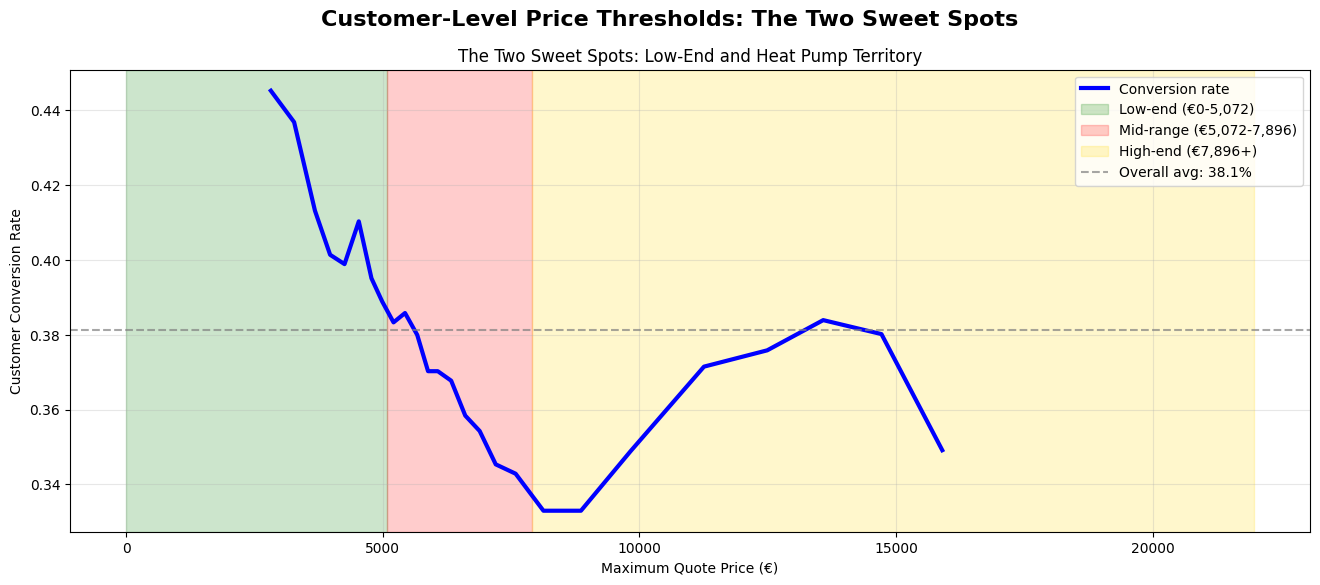

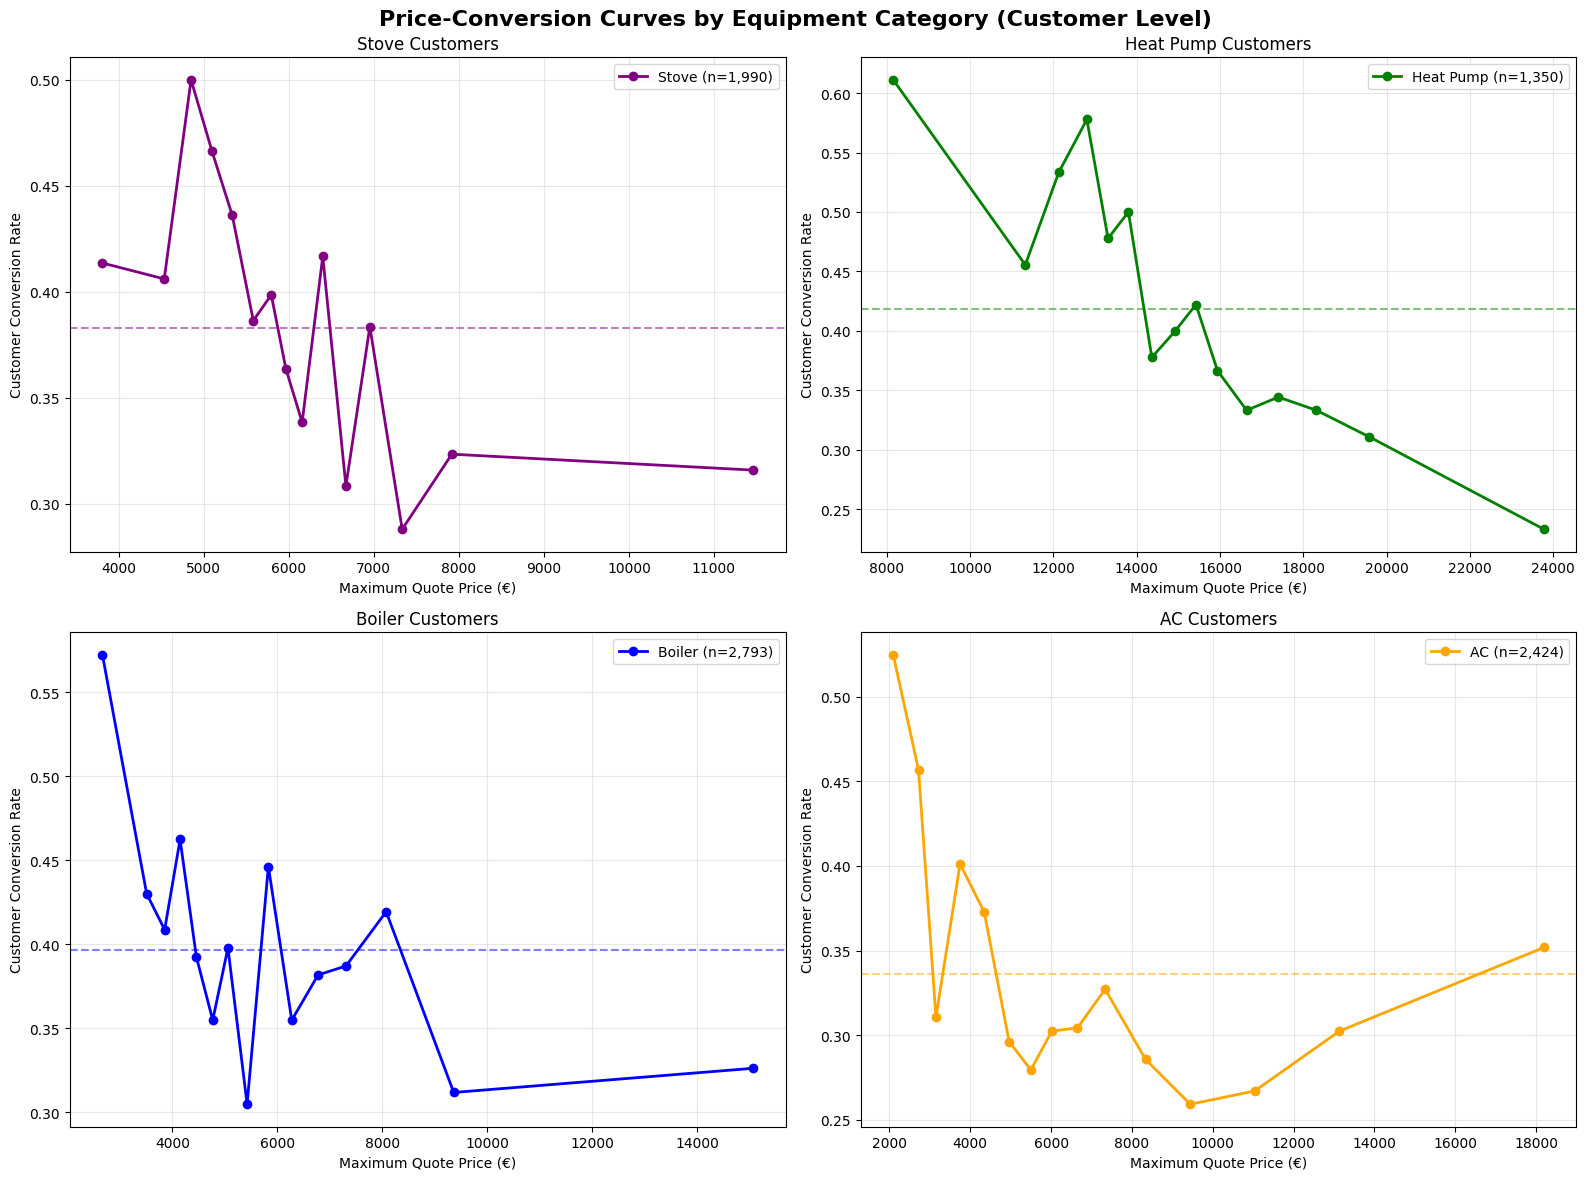


Conversion by Brand Price

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'DE DIETRICH', 'HITACHI']


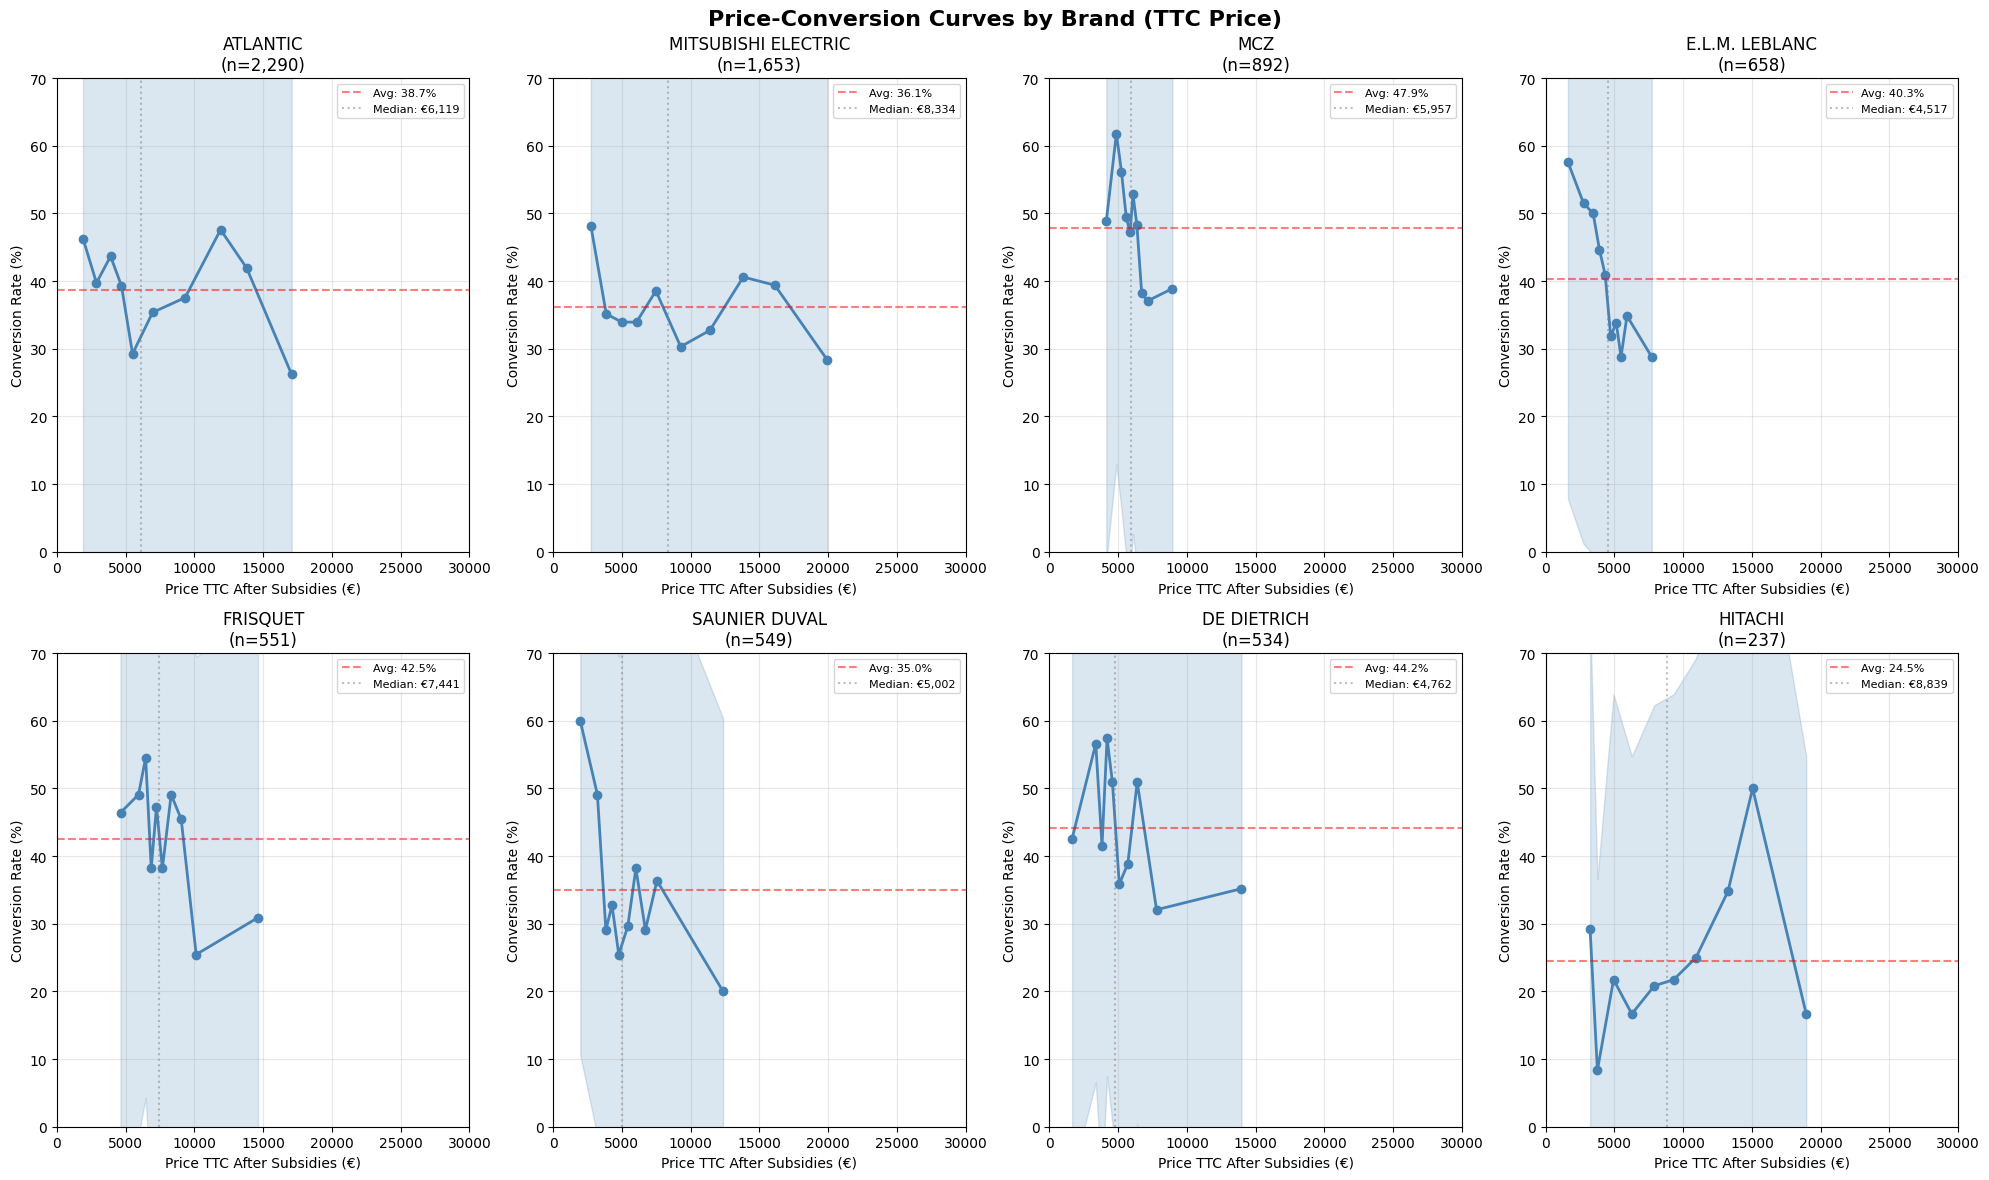


Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200


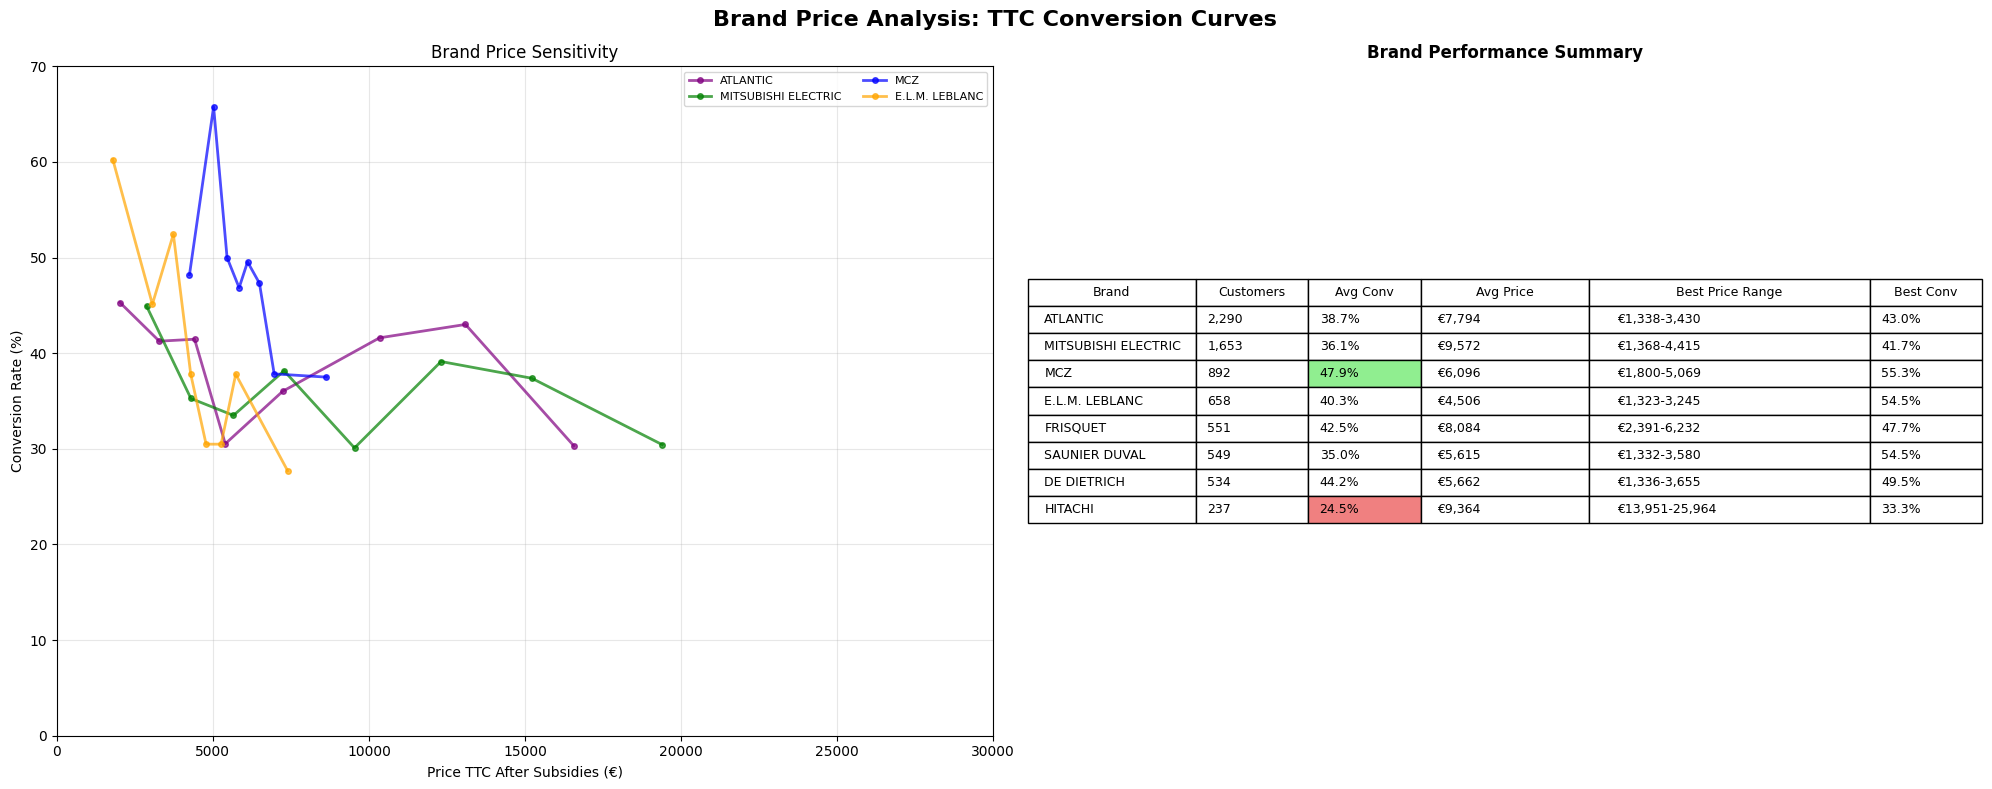


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'VIESSMANN', 'HITACHI']

Boiler - Top brands: ['E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'DE DIETRICH', 'ATLANTIC', 'VIESSMANN']

Stove - Top brands: ['MCZ', 'JOLLY MEC', 'ORANIER', 'PALAZZETTI', 'DOVRE', 'Edilkamin']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC', 'HITACHI', 'BOSCH', 'DAIKIN']


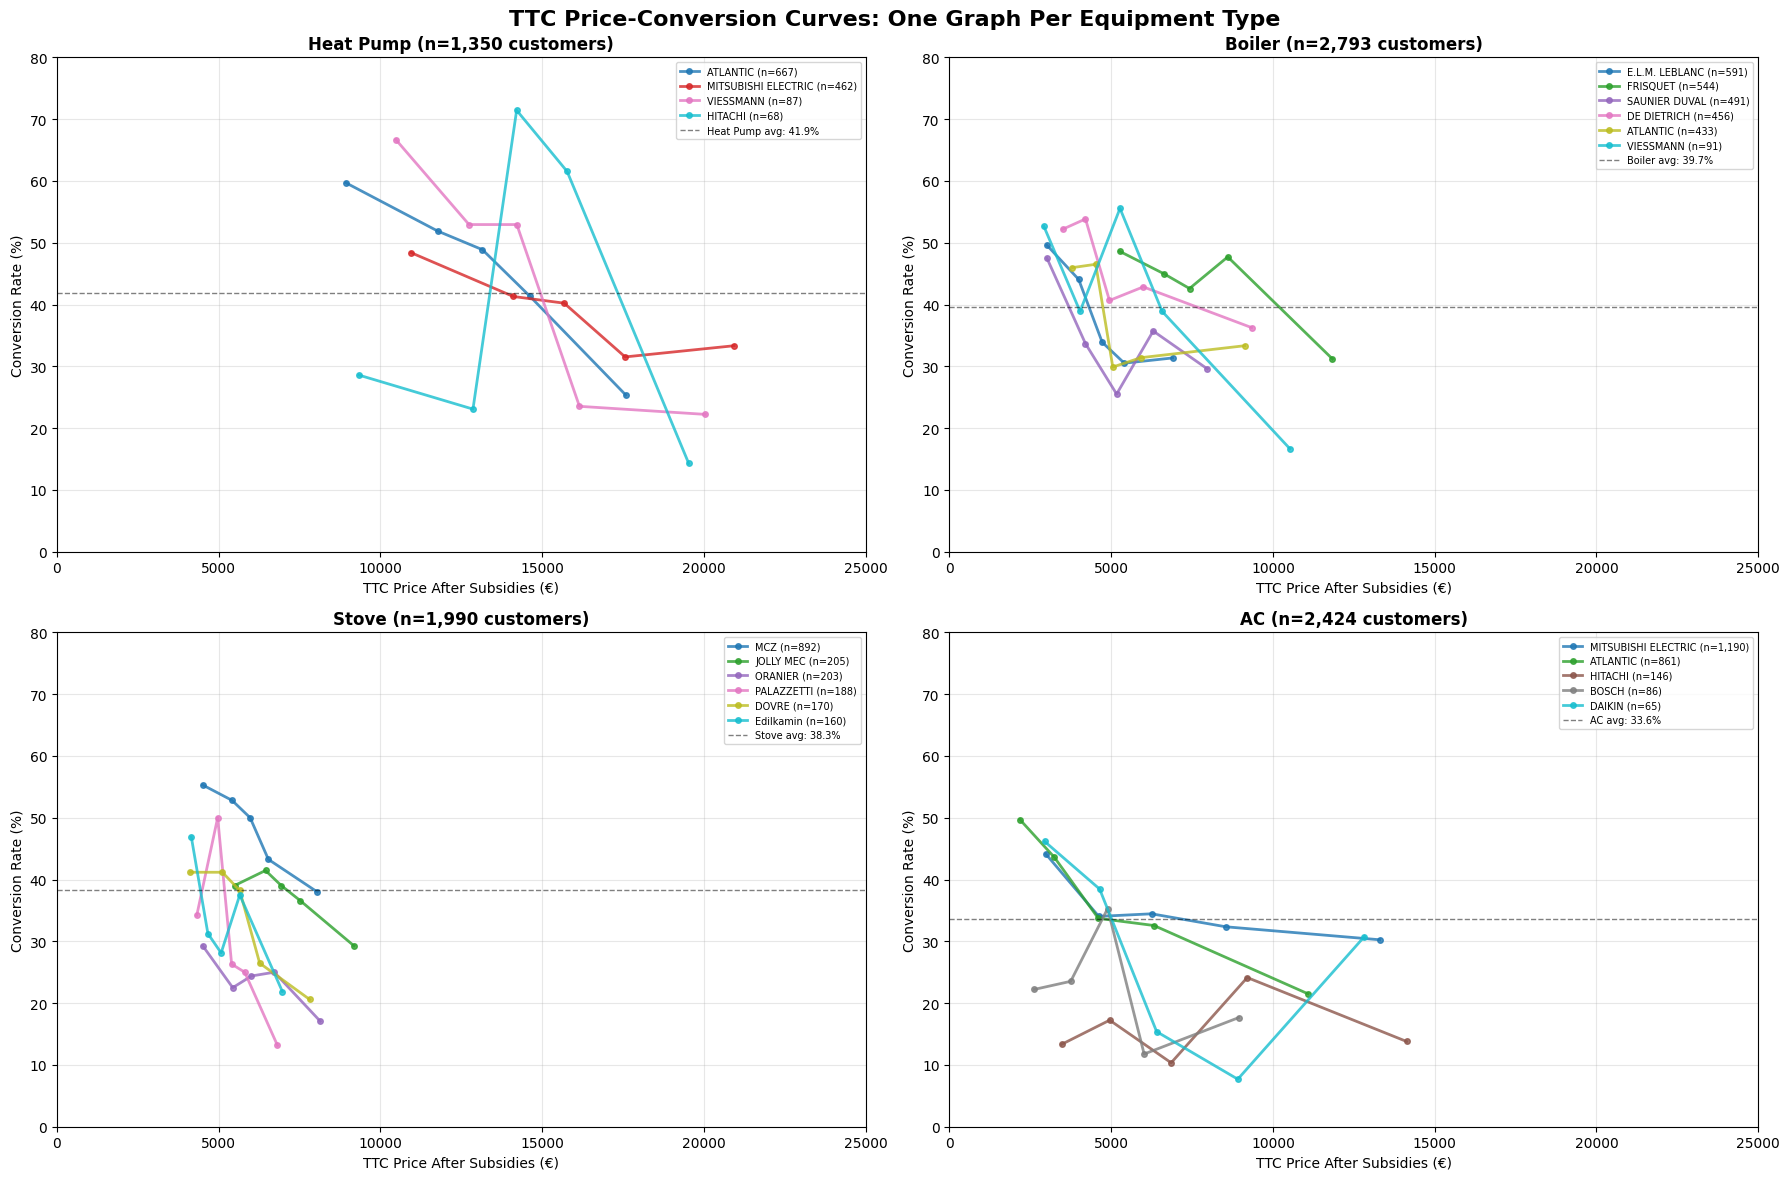


Seasonal Effects on Customer Conversion


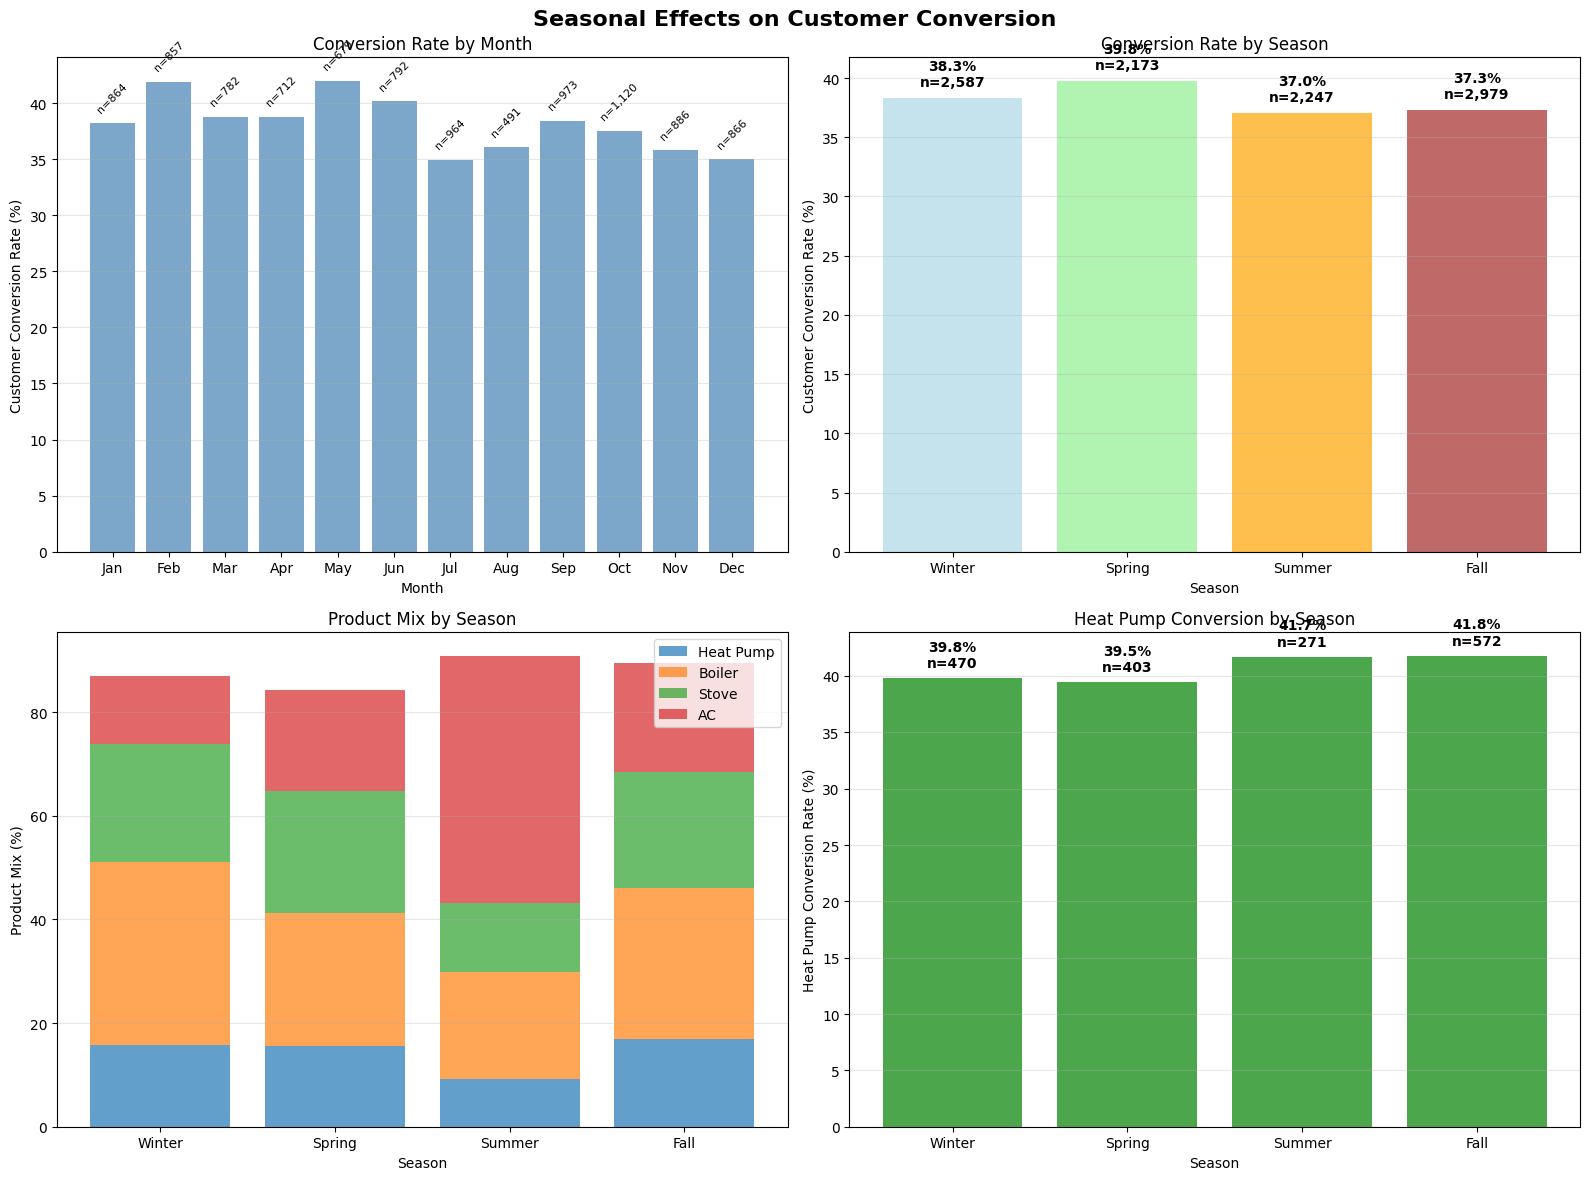


SEASONAL STATISTICS

Conversion by season:
  Winter: 38.3% (n=2,587)
  Spring: 39.8% (n=2,173)
  Summer: 37.0% (n=2,247)
  Fall: 37.3% (n=2,979)

Seasonality chi-square p-value: 0.2112
Statistically significant: NO

Regional Seasonal Pattern

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Top regions: ['Normandie', 'Auvergne-Rhône-Alpes', 'Hauts-de-France']


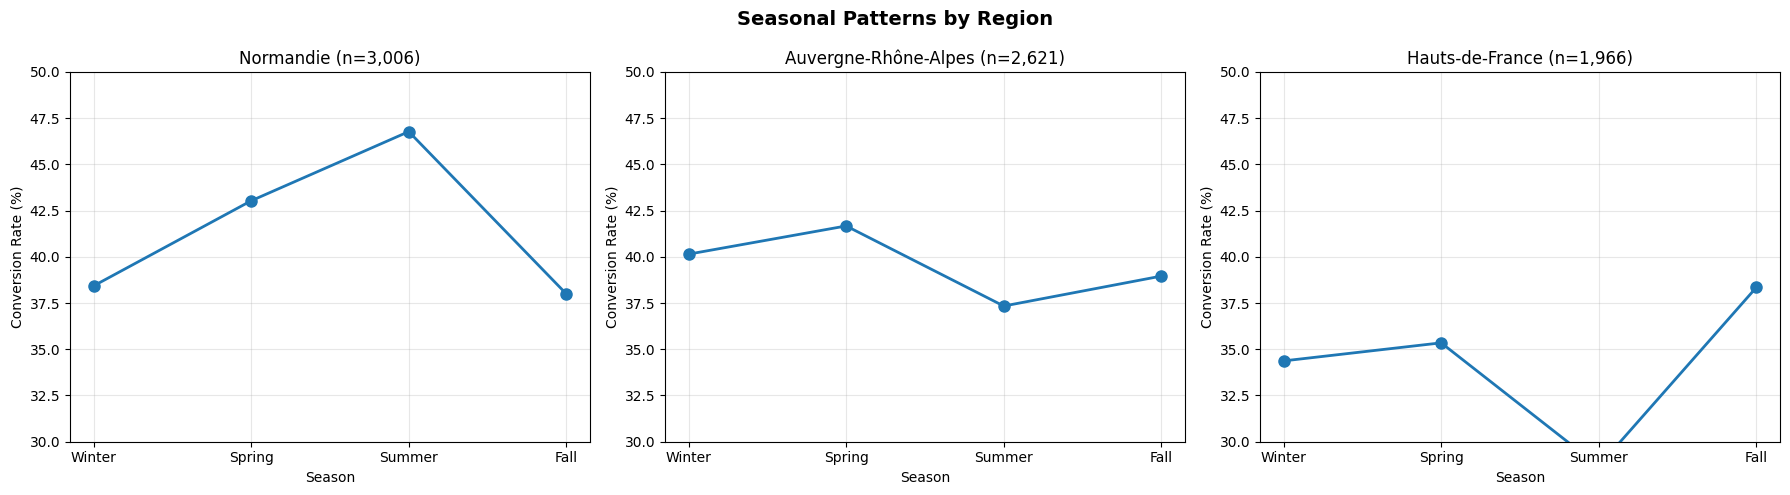


Year-over-year trends

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Quarterly conversion rates:
                  mean  count
year_quarter                 
2025Q1        0.398175   2411
2025Q2        0.405226   2105
2025Q3        0.366425   2347
2025Q4        0.361151   2780


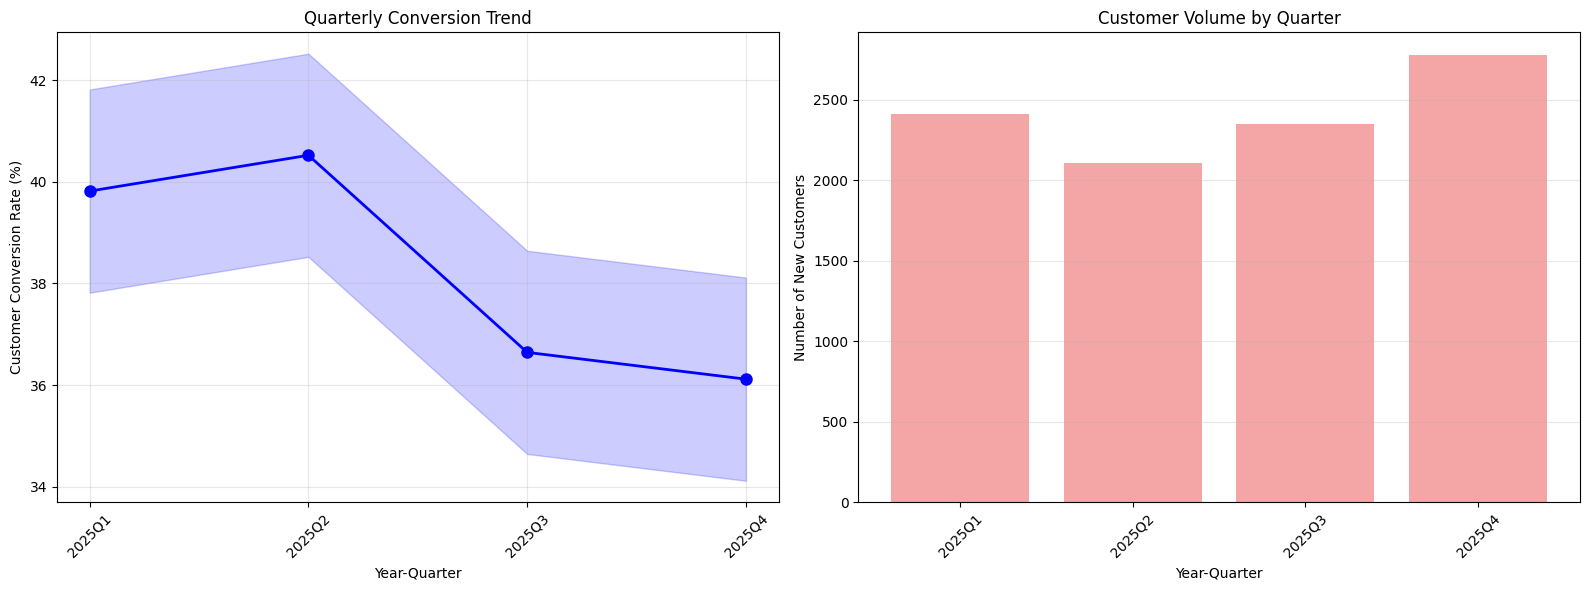


Best and Worst Months Report

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.386102   7296
During Suspension  0.366425   2347

Suspension impact p-value: 0.0924
Statistically significant: NO

Best month: 2 (42.3%, n=825)
Worst month: 7 (35.0%, n=934)

Best season: Spring (39.9%)
Worst season: Fall (37.1%)

Heat pump conversion by season:
  Winter: 40.5%
  Spring: 40.4%
  Summer: 43.4%
  Fall: 42.4%

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200


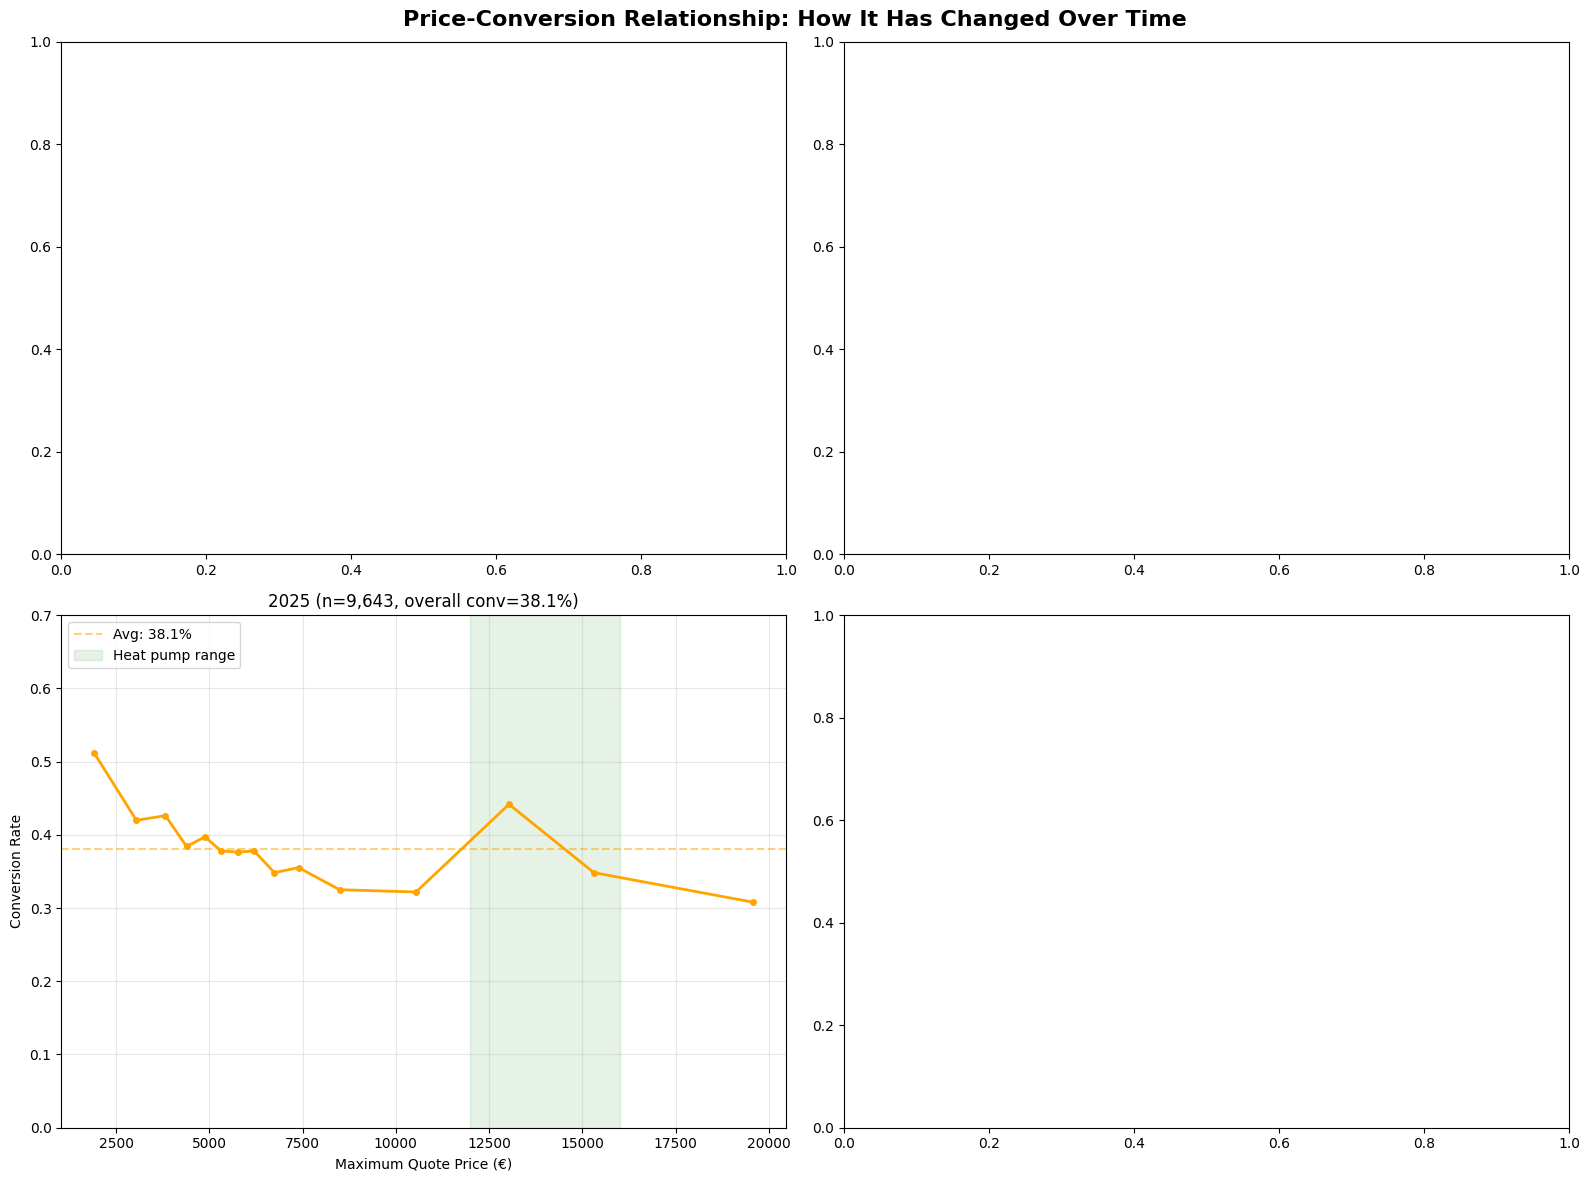


Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200


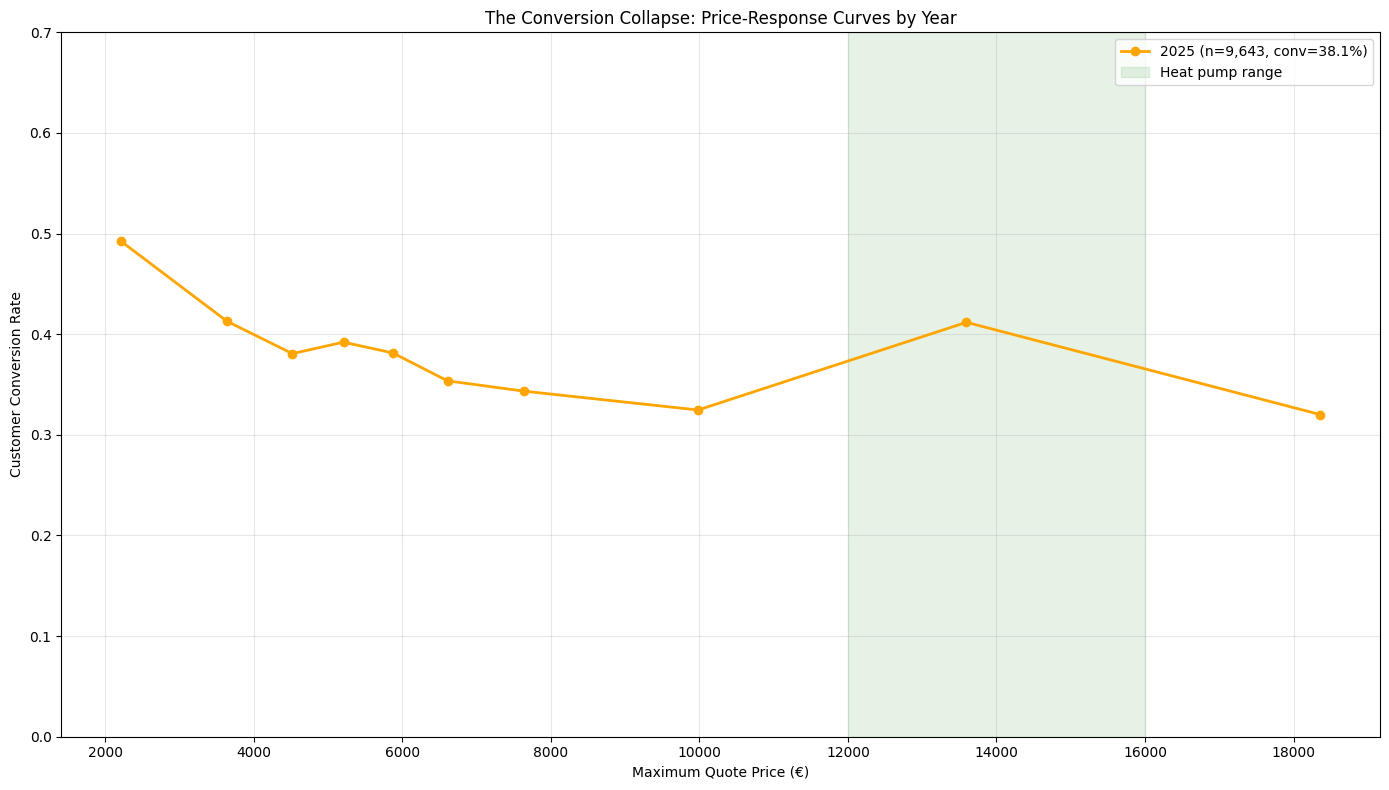


Sweet Spot Analysis Over Time

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Sweet spots by year (price points with conversion > avg + 3%):

2025 (overall avg: 38.1%):
  €1,748: 52.4% (n=483)
  €2,682: 46.1% (n=482)
  €3,900: 43.6% (n=482)
  €5,040: 42.1% (n=482)
  €12,766: 44.2% (n=482)


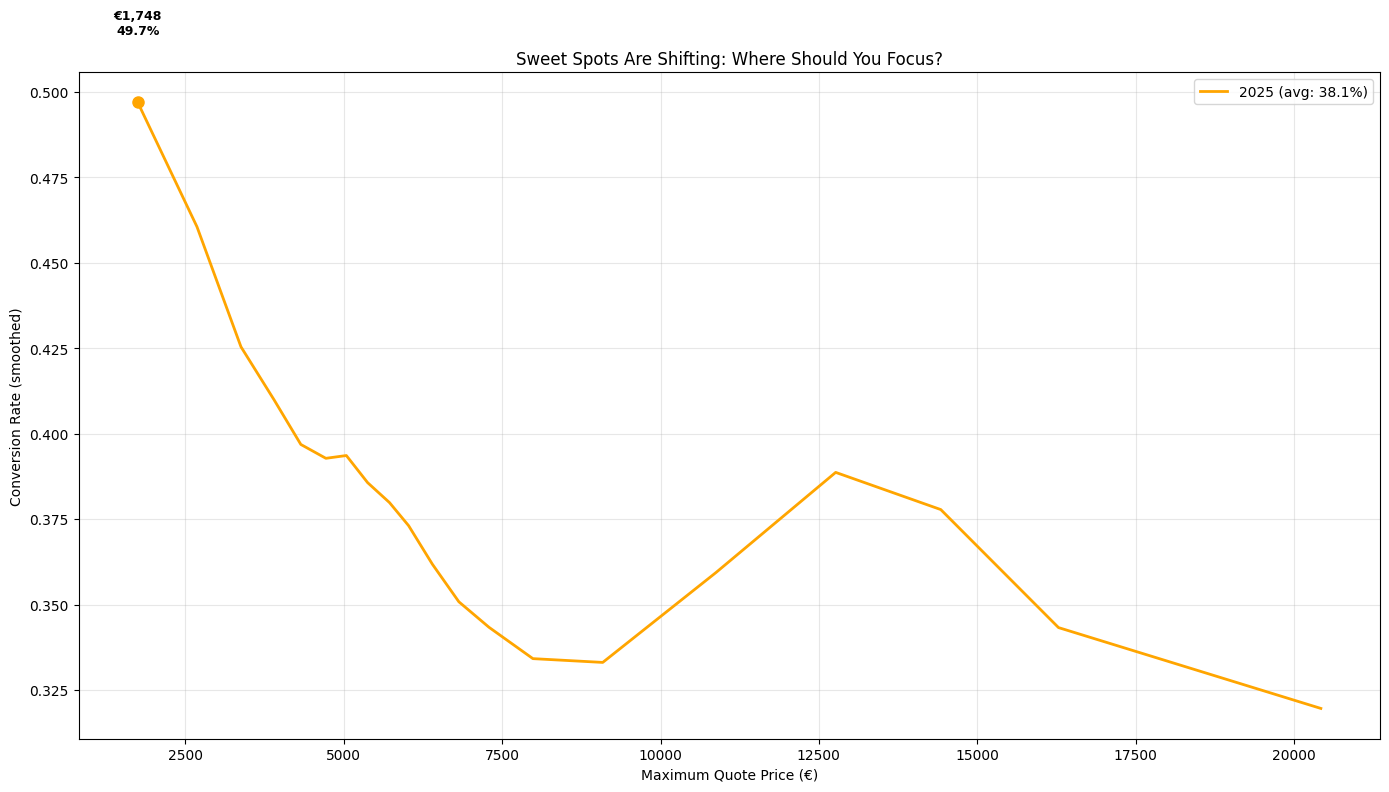


Administrative Uncertainty Effect

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Decision time distribution:
count    9643.000000
mean       10.095717
std        39.029109
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       429.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 8,116 (84.2%)


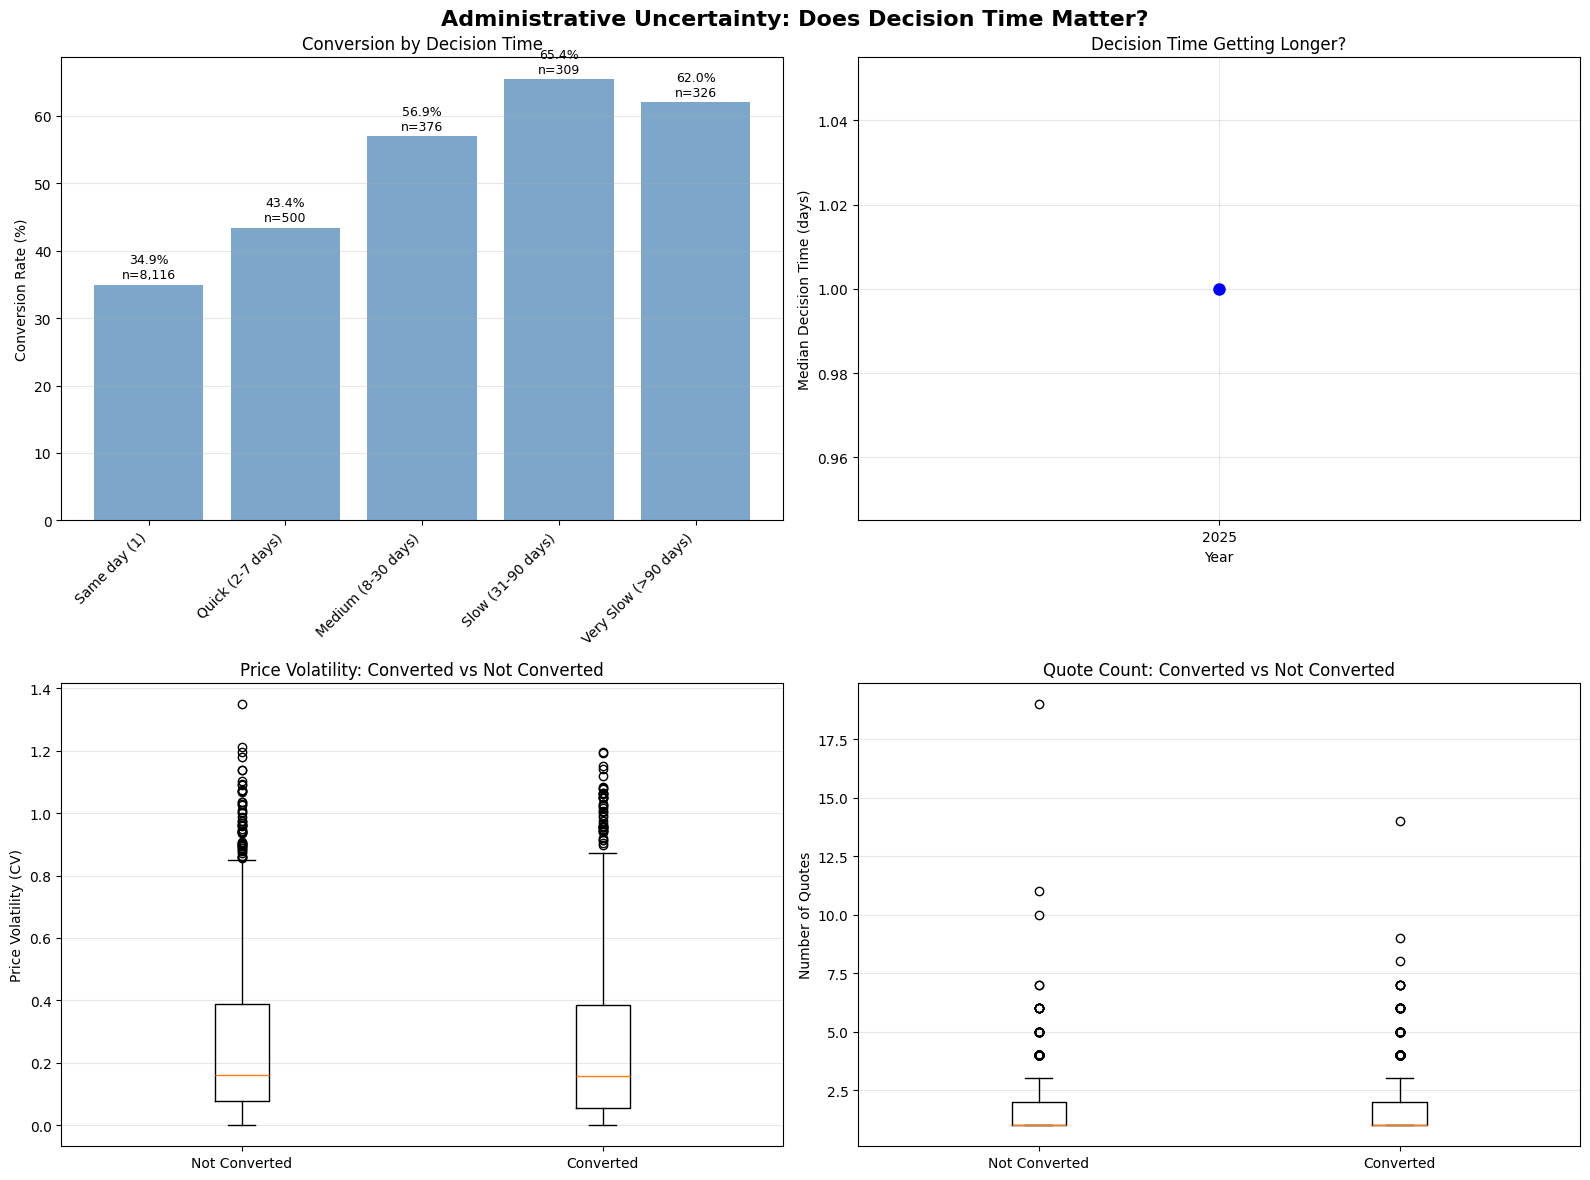


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1101.459, 4053.15]  (4053.15, 5529.27]  \
main_equipment_category                                            
AC                                 42.242704           32.445521   
Boiler                             47.761194           37.309942   
Heat Pump                          40.000000           71.428571   
Other                              46.763754           46.575342   
Stove                              42.528736           44.032258   

price_bin_simple         (5529.27, 7018.58]  (7018.58, 12092.49]  \
main_equipment_category                                            
AC                                29.594272            28.100471   
Boiler                            38.640133            36.912752   
Heat Pump                         37.500000            54.358974   
Other                             51.162791            26.174497   
Stove                             36.854460           

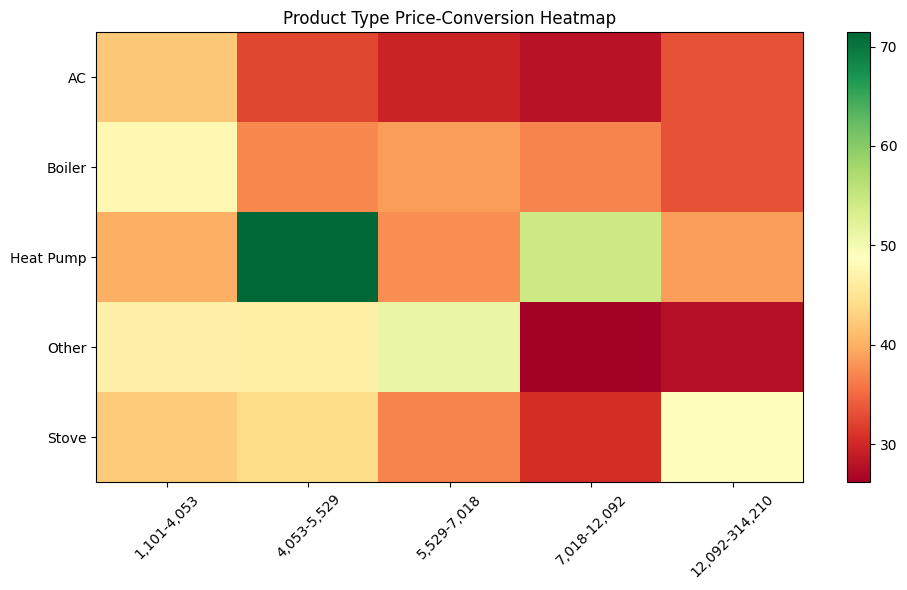


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           2886
Climatisation                       2475
Poêle                               2033
Pompe à chaleur                     1369
ECS : Chauffe-eau ou adoucisseur     550
Photovoltaïque                       255
Appareil hybride                     109
Emetteur de chauffage  ou chappe      98
Autres                                87
Unknown                               58
Accessoire de pose                    31
Produit VMC                           29
Plomberie Sanitaire                    6
Name: count, dtype: int64

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200


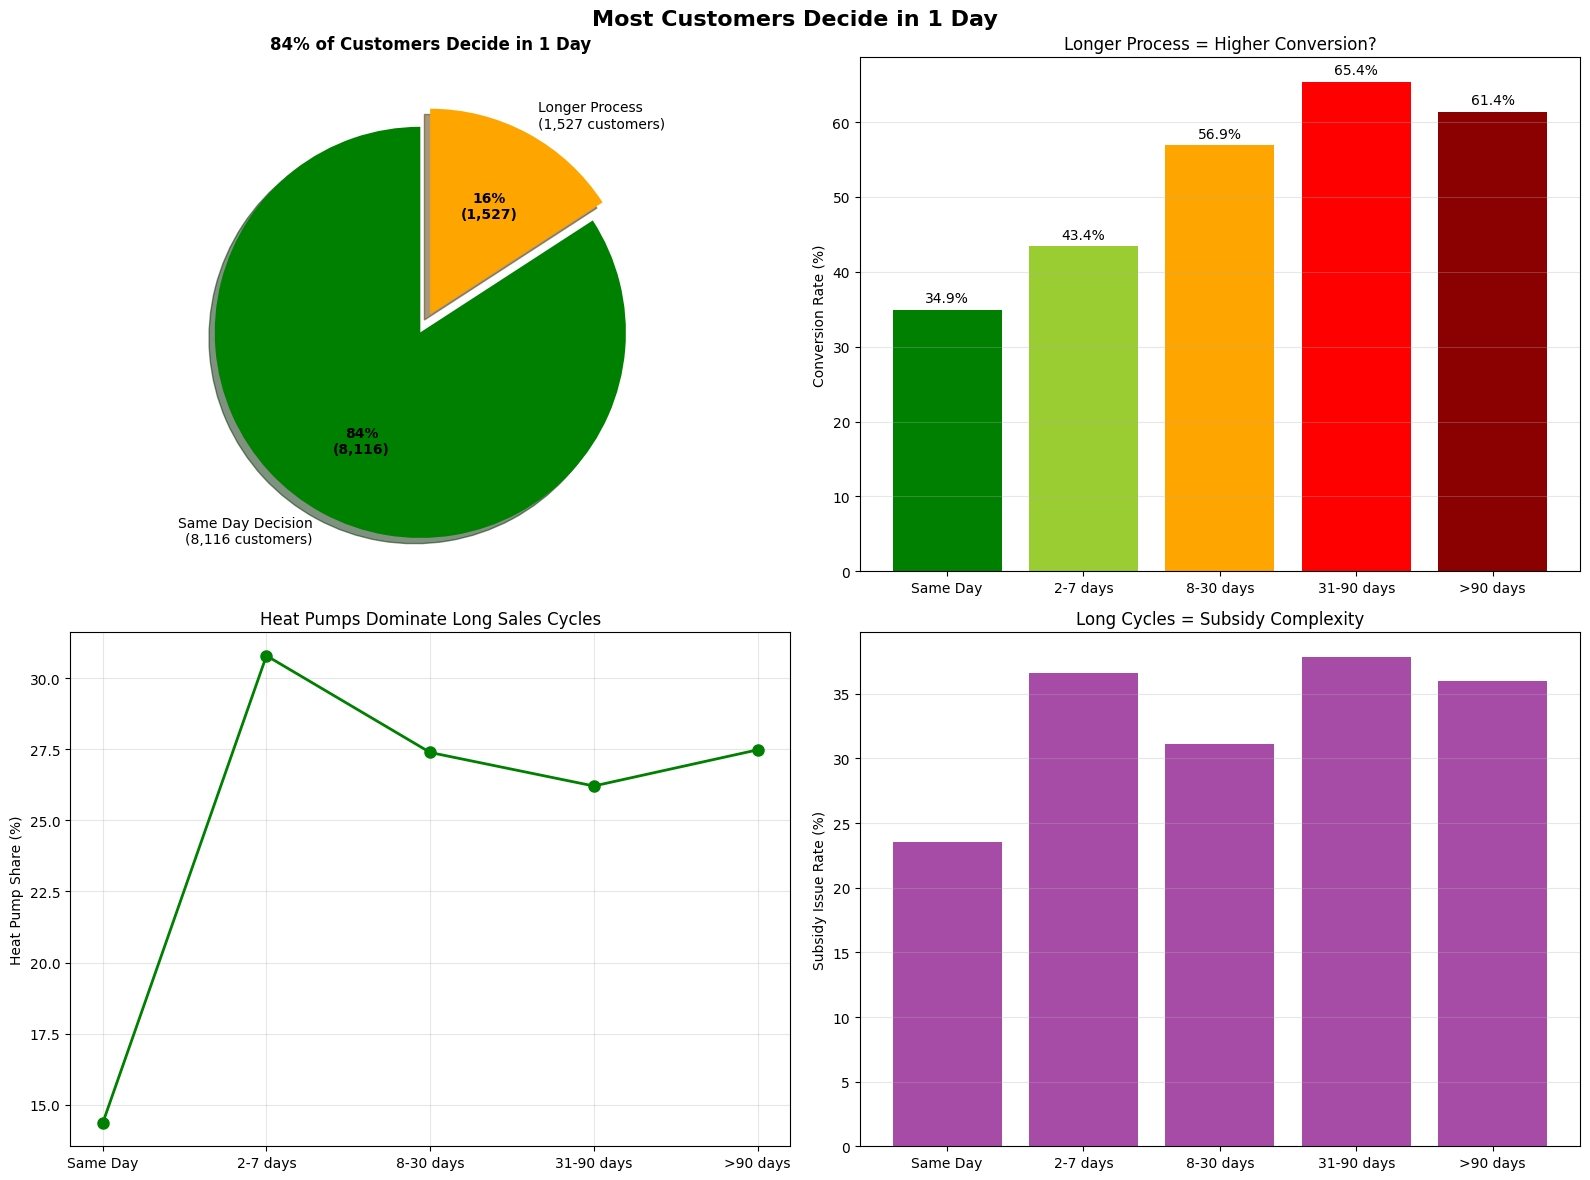


Heat Pump Performance Over Time

Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2025              0.416            1597  15227.259               0.753


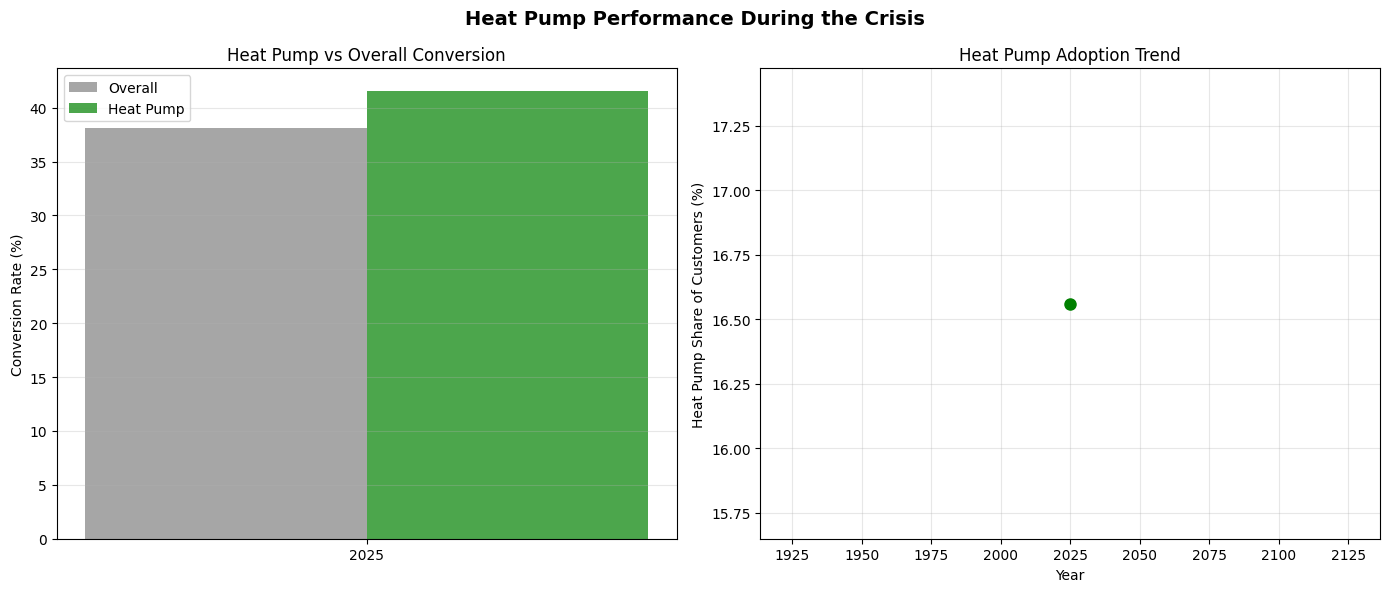


Analyzing 9,643 customers
Price range: €1,323 to €27,465
Median price: €6,200

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €1.6k (53.1%) and €2.2k (49.2%)
Dead zone: €18.7k-27.5k (30-34%)
Heat pumps: 75% subsidy issues, 41.6% conversion
Price sensitivity: Heat Pump (24.0pts) > AC (12.2pts) > Boiler (11.6pts) > Stove (11.5pts)
Same day decisions: 84%


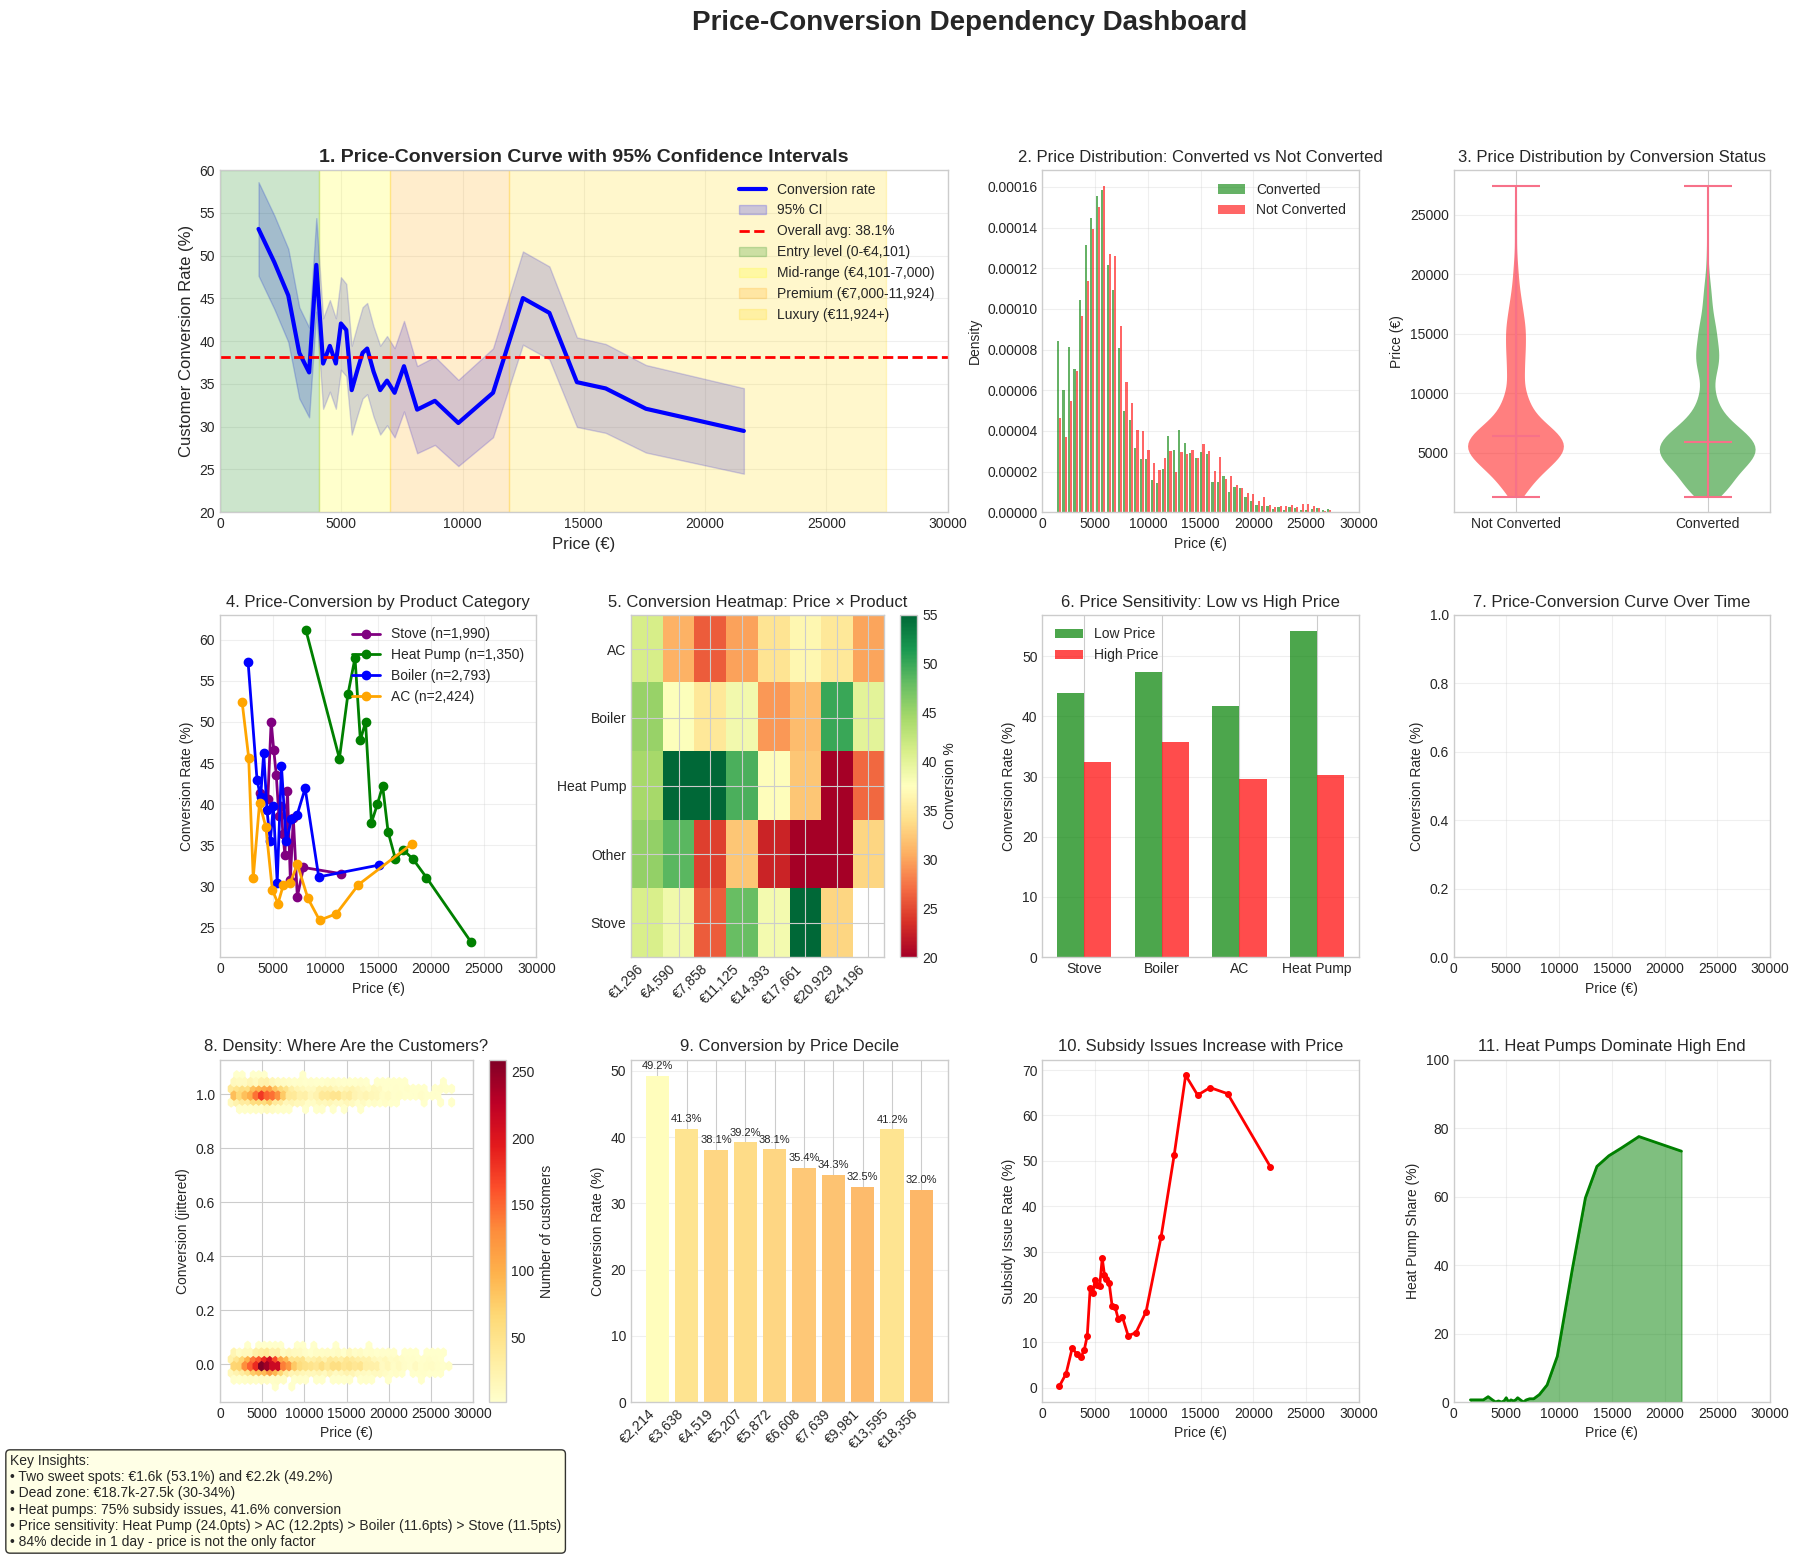

Actual product categories in data: ['AC', 'Boiler', 'Heat Pump', 'Other', 'Stove']


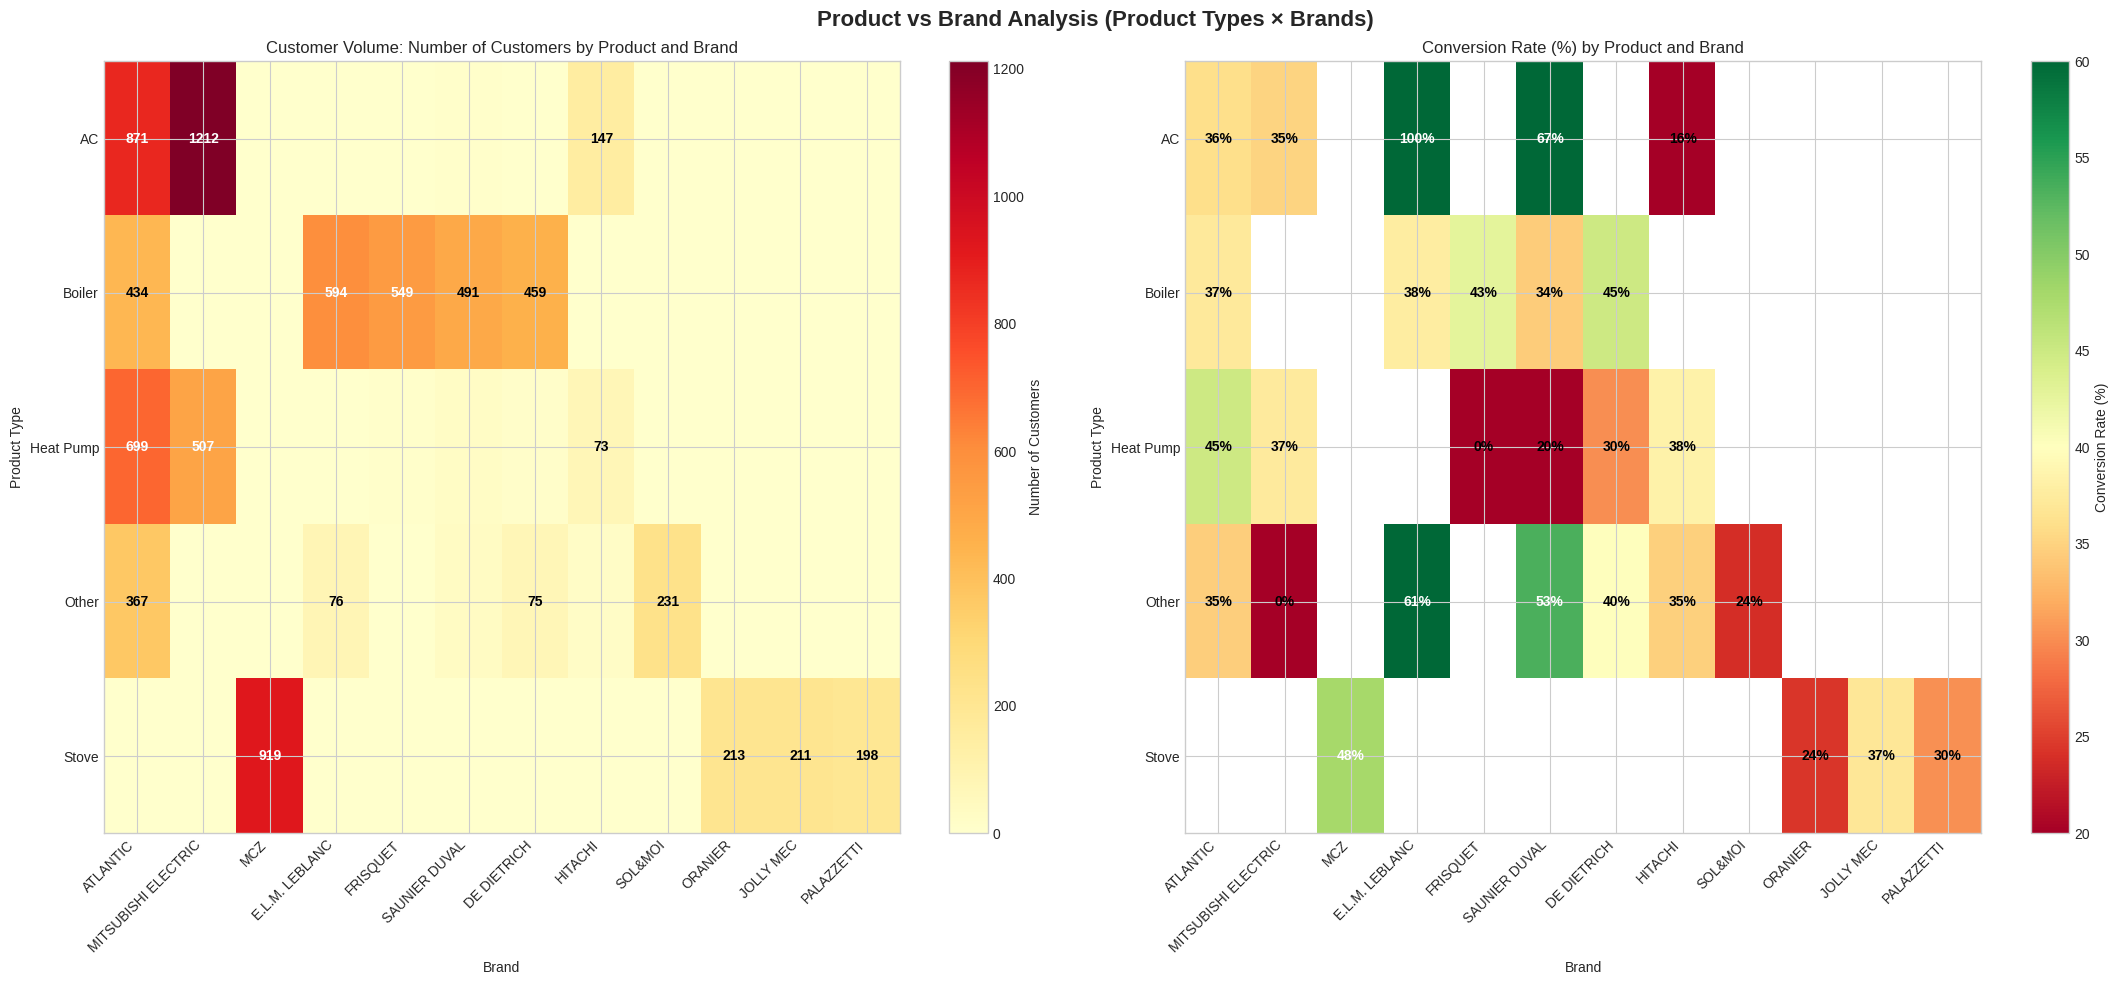


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC  MCZ  E.L.M. LEBLANC  FRISQUET  SAUNIER DUVAL  DE DIETRICH  HITACHI  SOL&MOI  ORANIER  JOLLY MEC  PALAZZETTI
main_equipment_category                                                                                                                                            
AC                            871                 1212    0               2         0              6            0      147        0        0          0           0
Boiler                        434                    0    0             594       549            491          459        0        0        0          0           0
Heat Pump                     699                  507    0               0         7             25           10       73        0        0          0           0
Other                         3

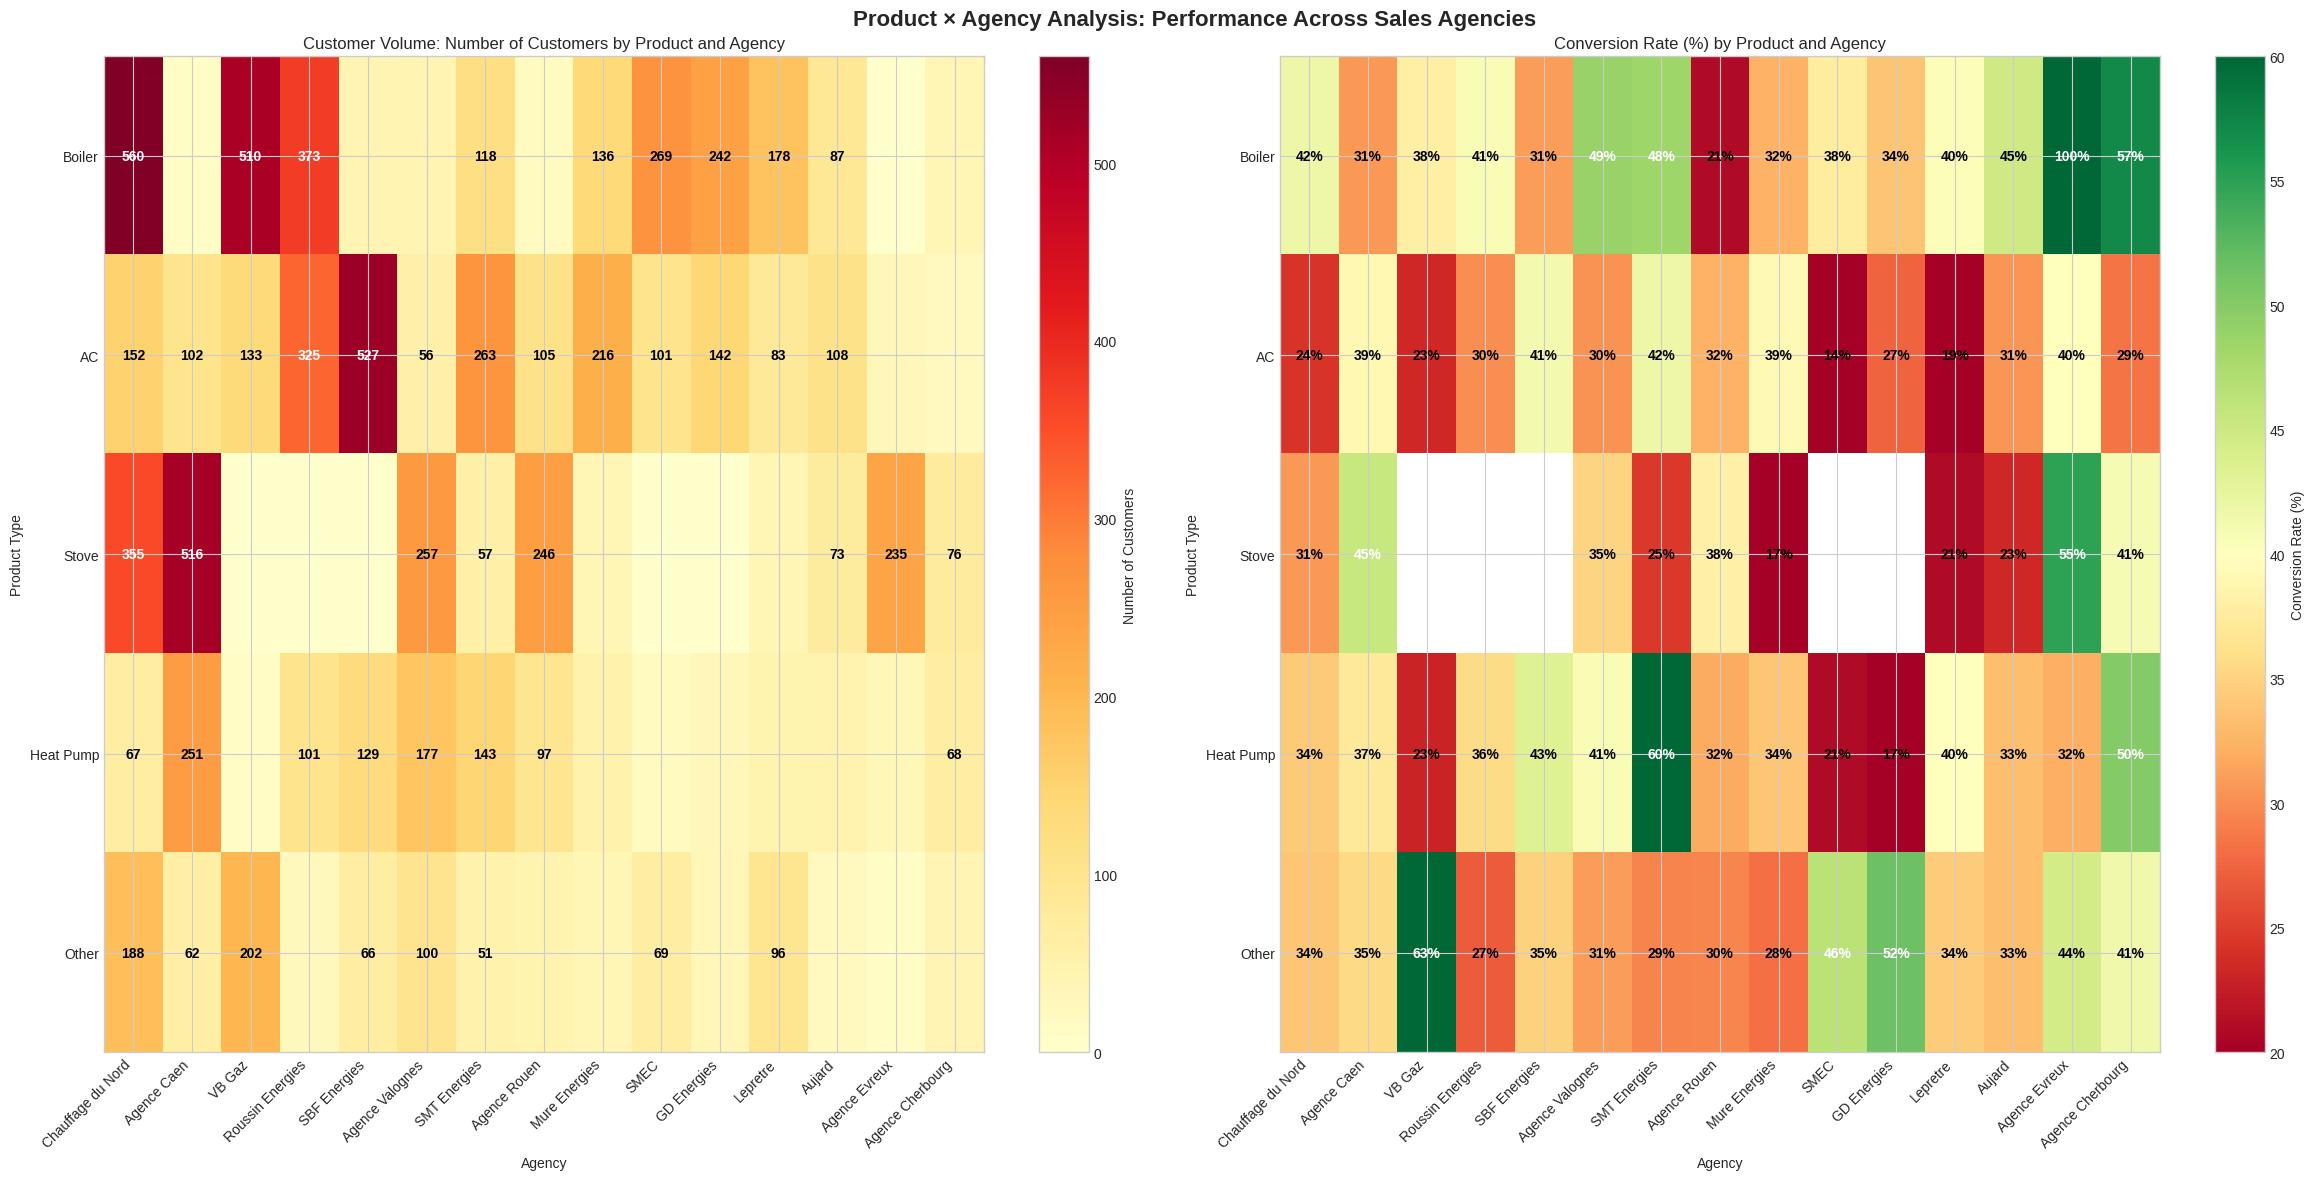


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              Chauffage du Nord  Agence Caen  VB Gaz  Roussin Energies  SBF Energies  Agence Valognes  SMT Energies  Agence Rouen  Mure Energies  SMEC  GD Energies  Lepretre  Aujard  Agence Evreux  Agence Cherbourg
main_equipment_category                                                                                                                                                                                                          
Boiler                                 560           13     510               373            42               43           118            19            136   269          242       178      87              2                35
AC                                     152          102     133               325           527               56           263           105            

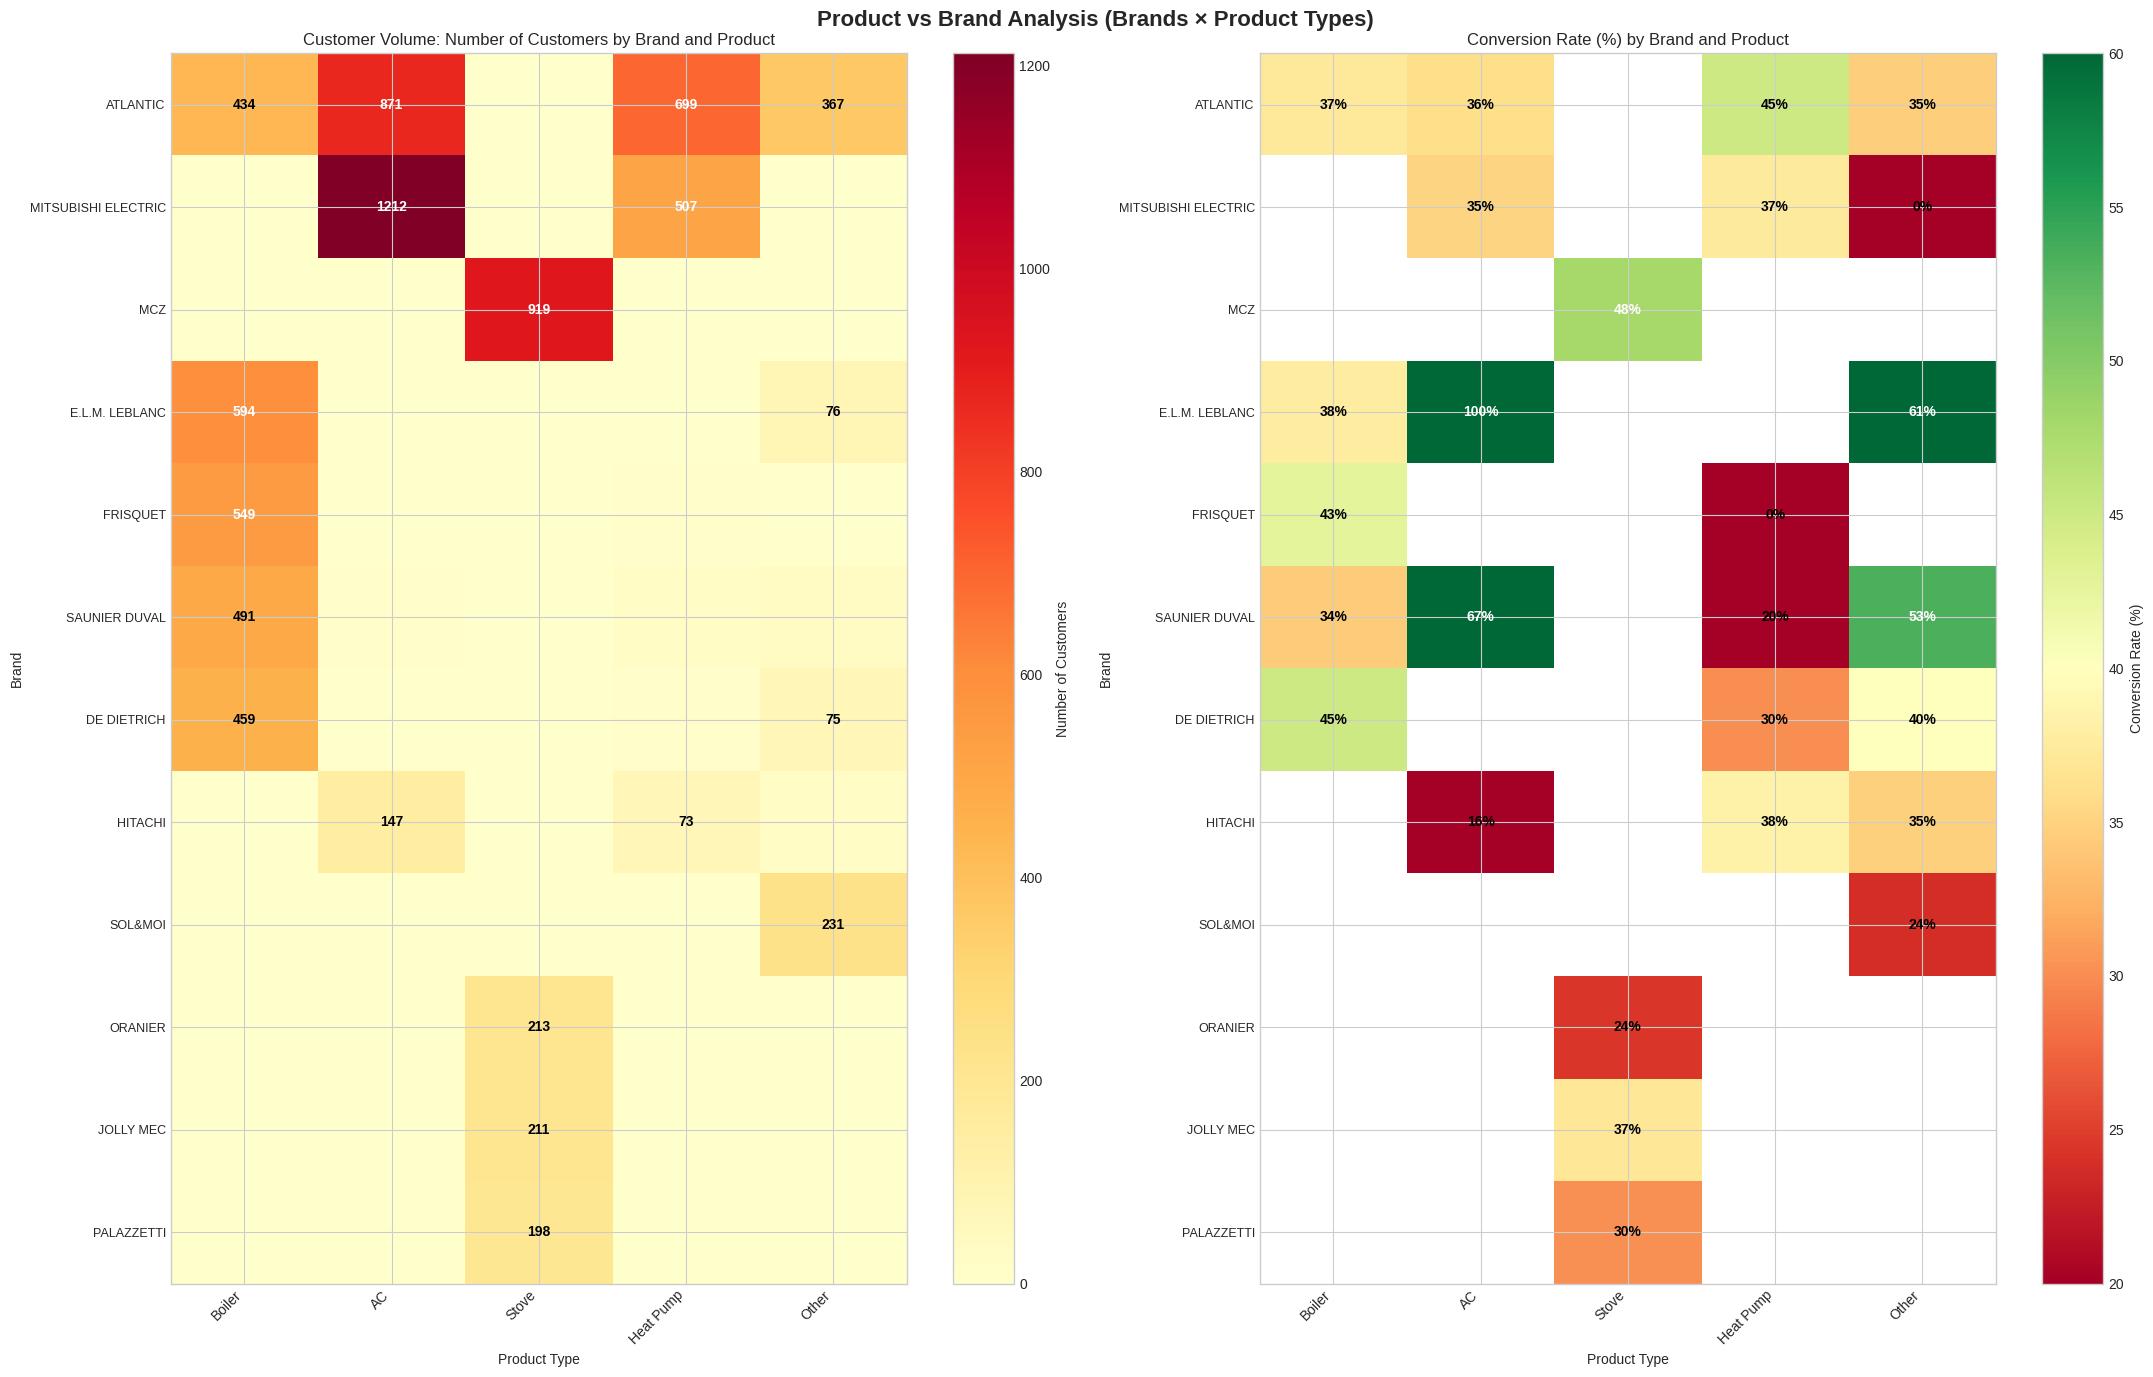


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category  Boiler    AC  Stove  Heat Pump  Other
main_brand                                                    
ATLANTIC                    434   871      0        699    367
MITSUBISHI ELECTRIC           0  1212      0        507      1
MCZ                           0     0    919          0      0
E.L.M. LEBLANC              594     2      0          0     76
FRISQUET                    549     0      0          7      0
SAUNIER DUVAL               491     6      0         25     30
DE DIETRICH                 459     0      0         10     75
HITACHI                       0   147      0         73     23
SOL&MOI                       0     0      0          0    231
ORANIER                       0     0    213          0      0
JOLLY MEC                     0     0    211          0      0
PALAZZETTI       

(main_equipment_category  Boiler    AC  Stove  Heat Pump  Other
 main_brand                                                    
 ATLANTIC                    434   871      0        699    367
 MITSUBISHI ELECTRIC           0  1212      0        507      1
 MCZ                           0     0    919          0      0
 E.L.M. LEBLANC              594     2      0          0     76
 FRISQUET                    549     0      0          7      0
 SAUNIER DUVAL               491     6      0         25     30
 DE DIETRICH                 459     0      0         10     75
 HITACHI                       0   147      0         73     23
 SOL&MOI                       0     0      0          0    231
 ORANIER                       0     0    213          0      0
 JOLLY MEC                     0     0    211          0      0
 PALAZZETTI                    0     0    198          0      0,
 main_equipment_category     Boiler          AC      Stove  Heat Pump  \
 main_brand                   

In [6]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [7]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

📓 Notebook: _eda_price_2025.ipynb
📄 PDF path: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025.pdf
🗑️ Removing existing PDF: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025.pdf
🔄 Converting to PDF...
✅ PDF saved: /home/valeriya/project/homeserve/ai-france-hvac/_eda_price_2025.pdf
